In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

import pickle

from PIL import Image
import os
import cv2
import random
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist,squareform
import networkx as nx
import random
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_squared_error
from itertools import product
from tqdm import tqdm


In [2]:
EMBEDDING_DIM = 4

# Functions

In [3]:
def knn_graph(matrix, k=5):
    G = nx.Graph()
    nbrs = NearestNeighbors(n_neighbors=k).fit(matrix)
    distances, indices = nbrs.kneighbors(matrix)
    
    for i in range(len(matrix)):
        G.add_node(i, pos=(matrix[i, 0], matrix[i, 1]))
        for j in indices[i]:
            if i != j:
                G.add_edge(i, j, weight=distances[i][np.where(indices[i] == j)[0][0]])
    
    return G

def plot_knn_graph(G,highlighted_nodes,polygon_mask):
    
    # Create a color map for nodes
    highlight_color = "#FF4500"
    node_colors = [highlight_color if node in highlighted_nodes else 'lightblue' for node in G.nodes()]
    #if pos == None:    
    pos = nx.get_node_attributes(G, 'pos')
    # Draw the graph
    fig,ax = plt.subplots(figsize=(8, 8))
    ax.imshow(polygon_mask, cmap='gray', alpha=0.3)
    nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax
    
def plot_scatter(pos,highlighted_nodes,polygon_mask):
    
    # Create a color map for nodes
    highlight_color = "#FF4500"
    node_colors = [highlight_color if i in highlighted_nodes else 'lightblue' for i in np.arange(1000)]
    #if pos == None:    
    #pos = nx.get_node_attributes(G, 'pos')
    # Draw the graph
    fig,ax = plt.subplots(figsize=(8, 8))
    ax.imshow(polygon_mask, cmap='gray', alpha=0.3)
    ax.scatter(pos[:,0],pos[:,1],s = 50,c = node_colors)
    #nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax


    #nx.draw(G, pos, with_labels=False, node_size=100, node_color='lightblue', edge_color='gray', alpha=0.6)
    #plt.show()

def plot_knn_graph_pos(G,highlighted_nodes,pos):
    #pos = nx.get_node_attributes(G, 'pos')
    highlight_color = "#FF4500"
    node_colors = [highlight_color if node in highlighted_nodes else 'lightblue' for node in G.nodes()]
    fig,ax = plt.subplots(figsize=(8, 8))
    nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, edge_color='gray', alpha=0.6,ax = ax)
    return fig,ax
    
def compute_kernel_matrix(X,k):
    D = squareform(pdist(X))
    D_s = np.argsort(D,axis=1)
    sig = np.median(D_s[:,(k+1)])
    #K = np.exp(-D**2/np.outer(sig,sig))    
    K = np.exp(-D**2/sig**2)    
    return K

def compute_laplacian(K):
    D_inv = np.diag(np.sum(K,axis = 1)**(-0.5))
    L = D_inv@K@D_inv
    return L

def compute_leading_eigenvectors(L,d):
    lam,v = np.linalg.eigh(L)
    sort_idx = np.argsort(lam)[::-1]
    lam = lam[sort_idx]
    v = v[:,sort_idx]
    return lam[:d],v[:,:d]

    

In [4]:

def load_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (image.shape[1] // 4, image.shape[0] // 4))  # Reduce size by half
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    return image, hsv

def detect_shapes(image):
    polygon_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    rectangles = []
    circles = []
    
    # Define color ranges
    black_lower = np.array([0, 0, 0])
    black_upper = np.array([180, 255, 50])
    blue_lower = np.array([100, 150, 50])
    blue_upper = np.array([140, 255, 255])
    green_lower = np.array([40, 50, 50])
    green_upper = np.array([90, 255, 255])
    
    # Detect black polygon
    black_mask = cv2.inRange(image, black_lower, black_upper)
    contours, _ = cv2.findContours(black_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        cv2.drawContours(polygon_mask, [contour], -1, 255, thickness=cv2.FILLED)
    
    # Detect blue rectangles
    blue_mask = cv2.inRange(image, blue_lower, blue_upper)
    contours, _ = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        rectangles.append((x, y, w, h))
    
    # Detect green circles
    green_mask = cv2.inRange(image, green_lower, green_upper)
    contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        (x, y), radius = cv2.minEnclosingCircle(contour)
        circles.append((int(x), int(y), int(radius)))
    
    return polygon_mask, rectangles, circles


def generate_random_points(mask, num_points=1000):
    points = []
    h, w = mask.shape
    while len(points) < num_points:
        x, y = random.randint(0, w-1), random.randint(0, h-1)
        if mask[y, x] == 255:
            points.append((x, y))
    return points

def build_graph(mask, rectangles):
    G = nx.grid_2d_graph(mask.shape[0], mask.shape[1])
    for x, y, w, h in rectangles:
        for i in range(x, x+w):
            for j in range(y, y+h):
                if (j, i) in G:                    
                    G.remove_node((j, i))
    return G

def compute_shortest_paths(G, points, circles):
    distance_matrix = np.zeros((len(points), len(circles)))
    for i, (px, py) in enumerate(points):
        if (i==10):
            print(i)
        for j, (cx, cy, _) in enumerate(circles):
            try:
                path_length = nx.shortest_path_length(G, (py, px), (cy, cx))
            except nx.NetworkXNoPath:
                path_length = float('inf')
            distance_matrix[i, j] = path_length
    return distance_matrix


# Ariel Example

In [61]:
image_path = 'C:\\Users\\Noa\\Documents\\Thesis\\data\\floor_plan_c.png'

image, gray = load_image(image_path)
print(image.shape)
polygon_mask, rectangles, circles = detect_shapes(gray)
print('generating points')
random_points = generate_random_points(polygon_mask)

(129, 210, 3)
generating points


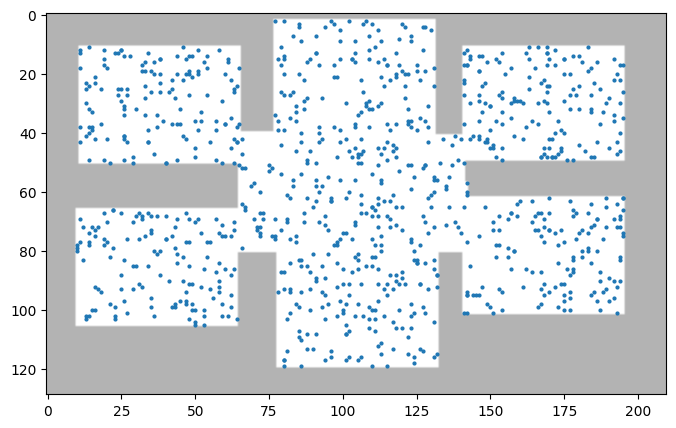

In [29]:
random_points = np.array(random_points)
fig,ax = plt.subplots(figsize=(8, 8))
ax.imshow(polygon_mask, cmap='gray', alpha=0.3)
ax.scatter(random_points[:,0],random_points[:,1],s = 4)
#print(random_points.shape)
    

In [30]:
G = build_graph(polygon_mask, rectangles)
distance_matrix = compute_shortest_paths(G, random_points, circles)

10


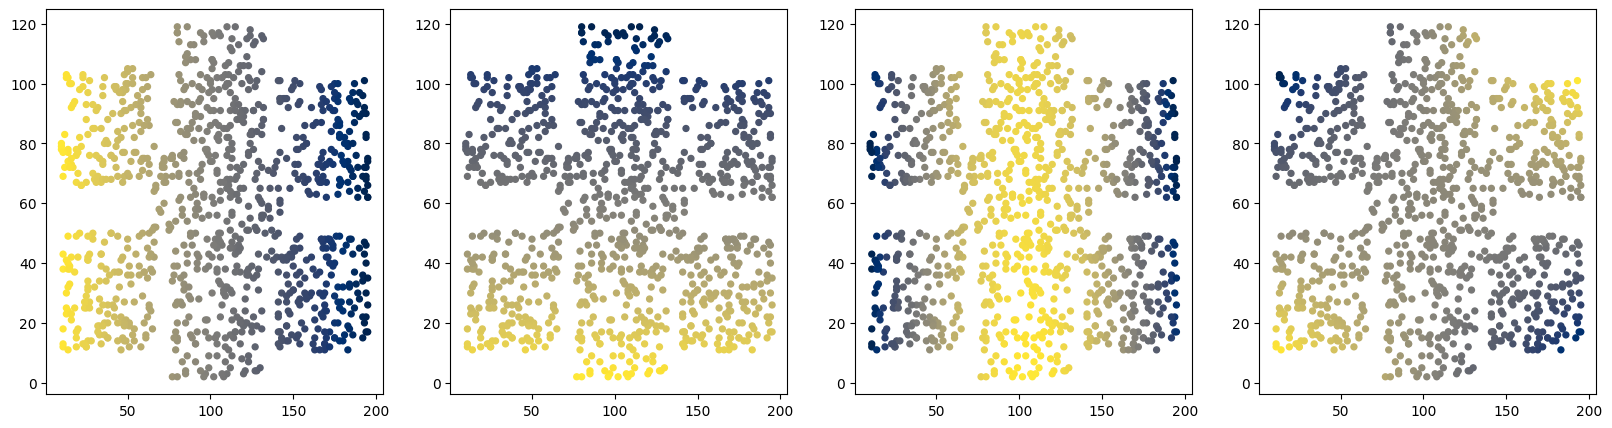

In [31]:
K_p = compute_kernel_matrix(np.array(random_points),k = 7)
L_p = compute_laplacian(K_p)
#D_s = np.argsort(D,axis=1)
#    sig = D_s[:,(k+1)]
#    K = np.exp(-D**2/np.outer(sig,sig))
lam,v_p = compute_leading_eigenvectors(L_p,30)
fig,axs = plt.subplots(1,4,figsize = (20,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(random_points[:,0],random_points[:,1],c = v_p[:,i+1],s = 18,cmap = 'cividis')
fig.savefig('eigenvectors_location.png')


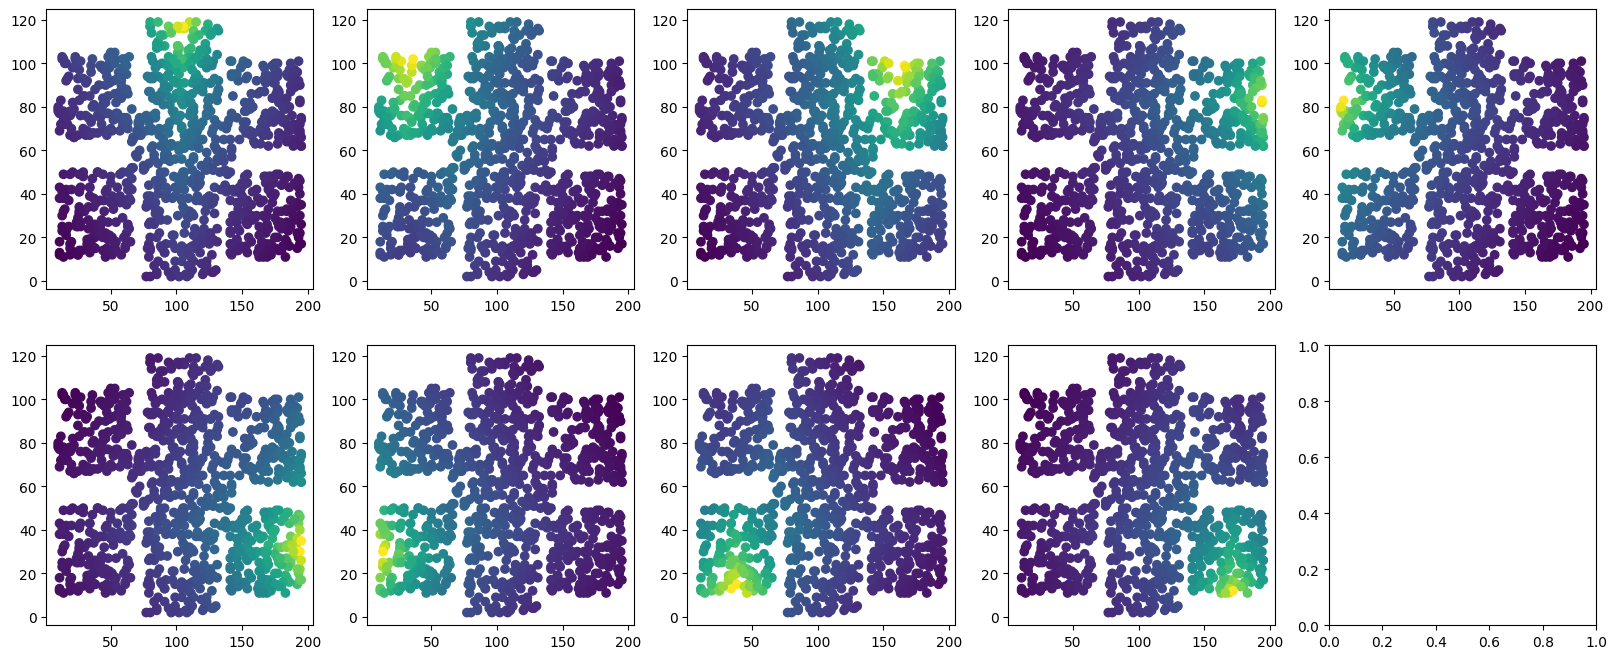

In [32]:
random_points = np.array(random_points)
fig,axs = plt.subplots(2,5,figsize = (20,8))
for i,ax in enumerate(axs.flatten()[:9]):
    ax.scatter(random_points[:,0],random_points[:,1],c = np.log(1/(distance_matrix[:,i]**2)))

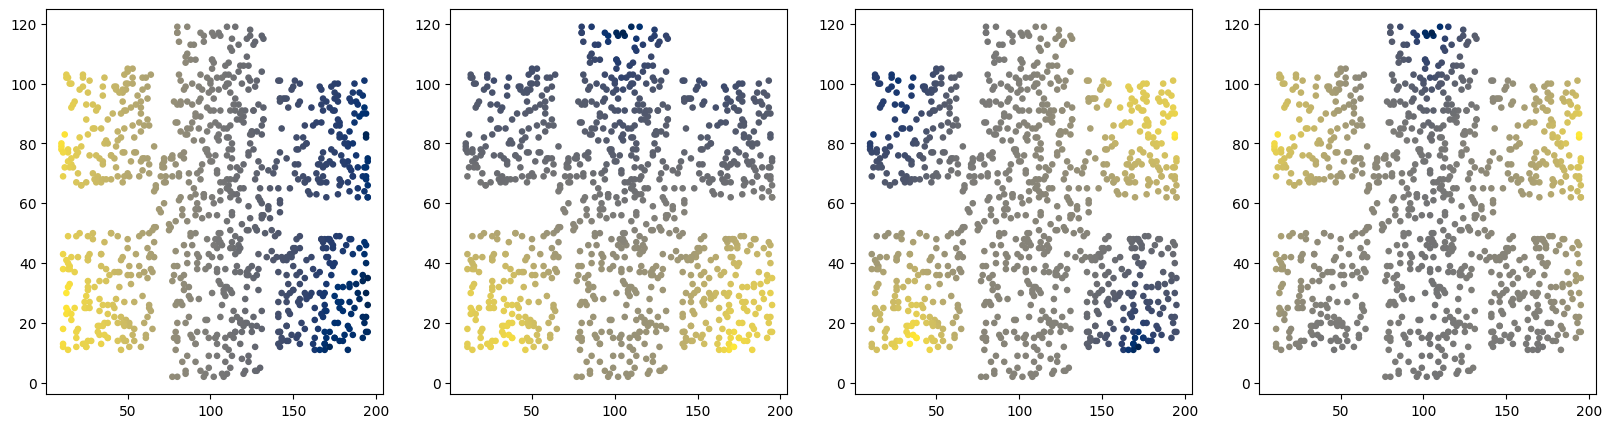

In [33]:
# signals 

K_sig = compute_kernel_matrix(np.log(1/(distance_matrix**2)),k = 7)
L_sig = compute_laplacian(K_sig)
#D_s = np.argsort(D,axis=1)
#    sig = D_s[:,(k+1)]
#    K = np.exp(-D**2/np.outer(sig,sig))
lam,v_sig = compute_leading_eigenvectors(L_sig,30) #Signals Embedding
fig,axs = plt.subplots(1,4,figsize = (20,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(random_points[:,0],random_points[:,1],c = v_sig[:,i+1],s = 14,cmap = 'cividis')
fig.savefig('eigenvectors_signals.png')

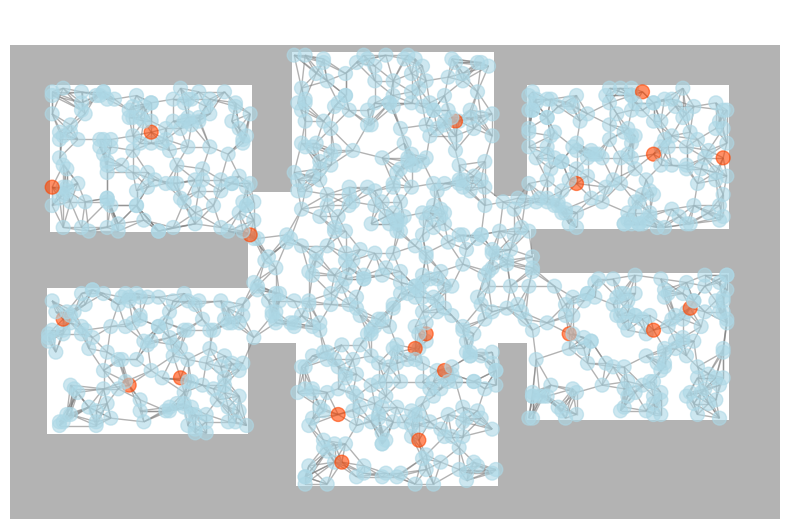

In [34]:
G_p = knn_graph(random_points,7)
highlighted = np.random.choice(np.arange(1000),size = 20,replace=False)
fig,ax = plot_knn_graph(G_p,highlighted,polygon_mask)
#ax.imshow(polygon_mask)
fig.tight_layout()
fig.savefig('graph_points.png')

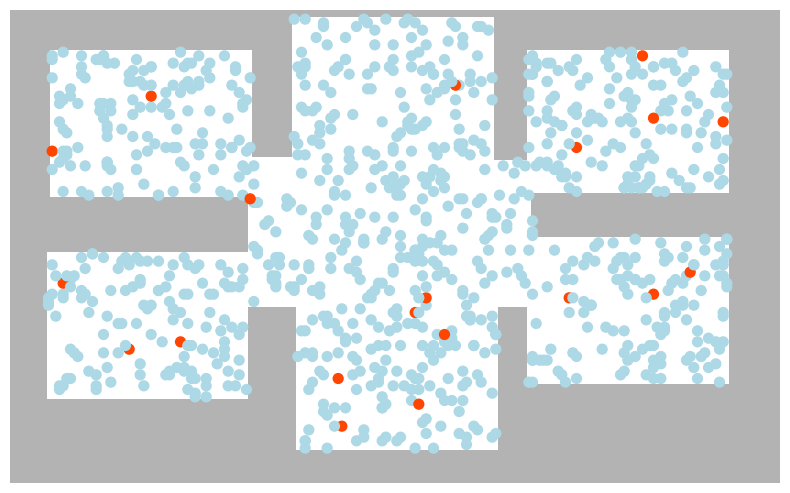

In [35]:
fig,ax = plot_scatter(random_points,highlighted,polygon_mask)
plt.axis('off')
fig.tight_layout()
fig.savefig('points_scatter.png')

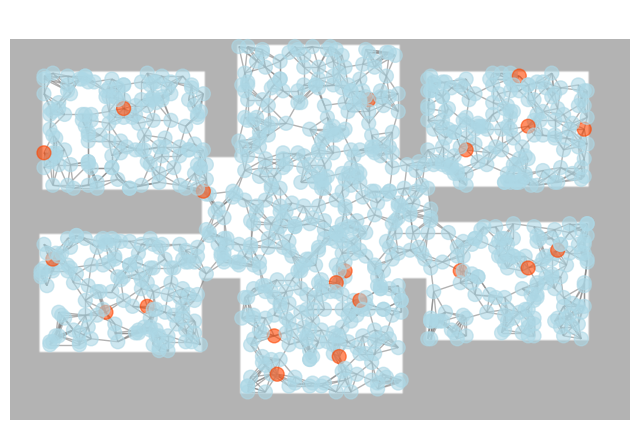

In [36]:
import matplotlib.colors as mcolors
fig,ax = plot_knn_graph(G_p,highlighted,polygon_mask)

#cmap = mcolors.ListedColormap([
#    (1, 1, 1, 1),    # White (Opaque)
#    (0.7, 0.7, 0.7, 0.3)  # Light Gray (50% Transparent)
#])
#bounds = [0, 0.5, 1]  # Define boundaries for 0 and 1
#norm = mcolors.BoundaryNorm(bounds, cmap.N)  # Normalize values

# Plot the binary image with imshow
#ax.imshow(polygon_mask, cmap=cmap, norm=norm)
#plt.axis('off')

In [37]:
polygon_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(129, 210), dtype=uint8)

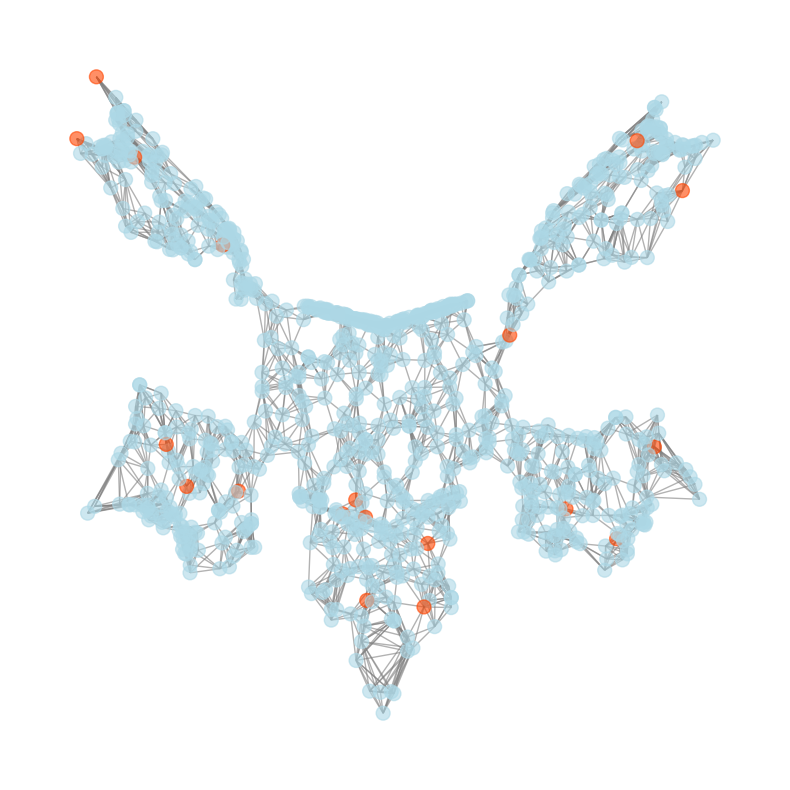

In [38]:
S = np.log(1/(distance_matrix**2))
G_sig = knn_graph(S,k = 10)
fig,ax = plot_knn_graph_pos(G_sig,highlighted,pos = v_sig[:,1:3])
#ax.plot(po)
fig.tight_layout()
fig.savefig('signals_graph.png')

# Robust example

In [5]:
class PhysicalLayoutGraph:
    def __init__(self, image_path, num_points=500, embedding_dim=EMBEDDING_DIM, k=7):
        self.image_path = image_path
        self.num_points = num_points
        self.embedding_dim = embedding_dim
        self.k = k
        self.random_points = None
        # self._process_image()
        # self._center_layout()

        self._build_graph()
        self._compute_adjacency()
        self.embedding = None
        self.dist_matrix = None

    def save_points(self,points):
        self.random_points = points
        

    def _process_image(self):
        image, gray = load_image(self.image_path)
        self.image = image
        self.gray = gray
        self.polygon_mask, self.rectangles, self.circles = detect_shapes(gray)
        #self.df_points_with_signals = {'x': random_points_from_graph[:, 0], 'y': random_points_from_graph[:, 1]}

    def _center_layout(self):
        """Center only the random points."""
        h, w = self.polygon_mask.shape
        self.center_point = np.array([w // 2, h // 2])
        self.random_points = np.array(generate_random_points(self.polygon_mask, num_points=self.num_points))
        # self.A_mean = np.round(A_all.mean(axis=0, keepdims=True)).astype(int)
        # Center only the random points
        # self.random_points = A_all - self.A_mean
        
    def _build_graph(self):
        self.G = build_graph(self.polygon_mask, self.rectangles)
        # self.random_points = generate_random_points(self.polygon_mask, num_points=self.num_points)
        # A_all = np.array(self.random_points)
        # self.A_mean = np.round(A_all.mean(axis=0, keepdims=True)).astype(int)
        # centered_A = A_all - self.A_mean
        # self.random_points = centered_A

    def _compute_adjacency(self):
        self.kernel_matrix = compute_kernel_matrix(self.random_points, k=self.k)

    def _compute_embedding(self, embedding_dim = EMBEDDING_DIM):
        L = compute_laplacian(self.kernel_matrix)
        print(embedding_dim + 1)
        lam, v = compute_leading_eigenvectors(L, embedding_dim + 1)
        self.embedding = v[:, 1:embedding_dim + 1]

    def get_embedding(self):
        return self.embedding

    def get_points(self):
        return self.random_points

    def plot_embedding(self):
        plt.figure(figsize=(6, 6))
        plt.scatter(self.embedding[:, 0], self.embedding[:, 1])
        plt.title("Physical Layout Spectral Embedding")
        plt.show()

    def plot_on_layout(self, predicted_points, true_points, title="Predicted Layout Locations"):
      plt.figure(figsize=(8, 8))
      plt.imshow(self.polygon_mask, cmap='gray', alpha=0.5)
      plt.imshow(self.image, alpha=0.3)

      predicted_p = np.array(predicted_points)
      plt.scatter(predicted_p[:, 0], predicted_p[:, 1], color='red', s=50, label="Predicted Points")

      true_p = np.array(true_points)
      plt.scatter(true_p[:, 0], true_p[:, 1], color='green', s=50, label="True Points")

      plt.legend()
      plt.title(title)
      plt.show()

    def embedding_to_layout_xy(self, embedding_points):
        """
        Maps points from embedding space to nearest real (x,y) layout points.
        """
        # Build KDTree of embedding
        tree = cKDTree(self.embedding)

        # Find nearest neighbor indices
        dists, indices = tree.query(embedding_points)

        # Map to (X, Y) points
        real_points = np.array(self.random_points)[indices]

        return real_points



In [6]:
class SignalGraph:
    def __init__(self, signal_data, embedding_dim=EMBEDDING_DIM, k_nearest=1):
        self.signal_data = signal_data
        self.embedding_dim = embedding_dim
        self.k_nearest = k_nearest
        self.embedding = None
        self._build_kernel()
        
    def _build_kernel(self):
        self.kernel_matrix = compute_kernel_matrix(self.signal_data, k=self.k_nearest)

    def _compute_embedding(self, embedding_dim):
        L = compute_laplacian(self.kernel_matrix)
        lam, v = compute_leading_eigenvectors(L, embedding_dim + 1)
        self.embedding = v[:, 1:embedding_dim + 1]

    def get_embedding(self):
        return self.embedding

    def plot_embedding(self):
        plt.figure(figsize=(6, 6))
        plt.scatter(self.embedding[:, 0], self.embedding[:, 1])
        plt.title("Signal Graph Spectral Embedding")
        plt.show()



In [7]:
class MatcherSSL:
    def __init__(self):
        self.fitted = False
        self.layout_graph = None
        self.signal_graph = None
        self.aligned_signal_embedding = None
        self.labeled_indices = None 

    def fit(self, layout_graph, signal_graph, labeled_indices):
        """
        Calibrate layout to signal space using SSL-style least squares.
        """
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph

        # phi_A = layout_embedding[labeled_indices]
        phi_S = self.signal_graph.embedding[labeled_indices]

        #centered
        A_all = np.array(self.layout_graph.get_points())
        self.A_mean = A_all.mean(axis=0, keepdims=True)  
        A_labeled = A_all[labeled_indices]
        centered_A = A_labeled - self.A_mean

        self.C, _, _, _ = np.linalg.lstsq( phi_S, centered_A, rcond=None)
        print(f"phi_S_dim :{phi_S.shape}, A_dim:{centered_A.shape}, C dim {self.C.shape}, ")
        print(self.C)
        A_all_centered = A_all - self.A_mean
        self.calibrated_phi_s = phi_S  @ self.C
        self.fitted = True
        return phi_S, centered_A, self.C, self.calibrated_phi_s

    def predict(self, validation_indices):
        """
        Predict layout locations for new signal vectors (not embeddings).
        Uses 1-NN matching in calibrated spectral space.
        """
        if not self.fitted:
            raise ValueError("Must call .fit() before .predict()")
        # self.calibrated_phi_s = self.calibrated_phi_s + self.A_mean
        self.calibrated_phi_s = self.signal_graph.embedding[validation_indices] @ self.C
        return self.calibrated_phi_s + self.A_mean

 

# run Microsoft Data 

In [8]:
file_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\df_preprocess_cleaned_5a0546857ecc773753327266_F1.csv"
image_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\metadata\5a0546857ecc773753327266\F3\floor_image.png"

In [9]:
data = pd.read_csv(file_path)
NUM_RECIVERS = len([c for c in data.columns if c not in ["x", "y"]])
print(NUM_RECIVERS)
points_with_signals_df = data.drop(columns=["Unnamed: 0"])

NUM_POINTS = 1000
EIG_V_DIM = 8

903


In [10]:
points_with_signals_df.head()

,000840e5c600de293cea57f13326f273c86c3988,00ad587dcb9c7ce3788b92e22777a22ee0efea31,00af060fc145ee6a6a50475efa57b91cbf54237f,00bcc61bdea4d52d050822d66952dd707c2fcdf3,00f0904087c01d922d6ebf3005607dfdeaf6687b,011e20ebf721a1c6dfec42e8ed1e2ac566073a2a,01d2f676abab6ec03ec5dc696bfd49d66e392ea1,01e25e4a25acd32baf5137b3031151f751fadbb4,026c2f057932da75680b21ecdbd23bf9cb9350f3,028a310e23177c3747d37971678dd964ee28ce17,...,fd1a502adb446e835797a88fad8e79d1e0bf4b4a,fd977a3af7be241a9ed0213acb3aa75e5dc00253,fdb1ad87bd6fb08014267f2586faeed0edc7412b,fdc189e5a19850397f37201f4acc378cfddcf0d6,fdc19f011587b75c11a6c30d8ca06d90107b6bde,fdf37fa13679f581bdfaae3b99e368633e0a144b,fdfe926caf5f49a88a9bcab8d025e887f422128b,ffa41c79865d7fb336f586e0dec8b080db1027fb,x,y
0,-91,-70,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-89,-100,-89,-74,-100,-89,32.941338,106.97777
1,-91,-70,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-84,-100,-87,-79,-100,-89,27.130260,111.62241
2,-91,-67,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-85,-100,-82,-79,-100,-100,27.130260,111.62241
3,-91,-67,-100,-100,-100,-100,-100,-100,-100,-100,...,-100,-100,-85,-100,-83,-86,-100,-100,27.130260,111.62241
4,-74,-100,-100,-82,-100,-100,-87,-100,-100,-100,...,-100,-100,-100,-100,-100,-86,-87,-100,80.155380,46.83941


# simulated data

In [11]:

# image_path = 'C:\\Users\\Noa\\Documents\\Thesis\\data\\floor_plan_c.png'
# NUM_POINTS = 1000
# EIG_V_DIM = 2
# NUM_RECIVERS = 9 # based on the floor image - filled manually


In [12]:
def create_dist_mat():
    layout_graph = PhysicalLayoutGraph(image_path, num_points=NUM_POINTS, embedding_dim=EIG_V_DIM, k=1)
    dist_matrix = compute_shortest_paths(layout_graph.G, layout_graph.random_points, layout_graph.circles)
    file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl"
    with open(file_path_name, "wb") as f:
        pickle.dump({'dist_matrix': dist_matrix, 'layout_graph': layout_graph}, f)
    # pd.to_pickle(dist_matrix, fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl")


def load_dist_mat():
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_1000points_9recivers.pkl"
    path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft_data_dist_mat.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
    dist_matrix = data['dist_matrix']
    layout_graph = data['layout_graph']

    if not os.path.exists(path):
        raise FileNotFoundError(f"Distance matrix file not found at {path}")
    return layout_graph, dist_matrix


In [13]:
create_dist_mat()

AttributeError: 'PhysicalLayoutGraph' object has no attribute 'polygon_mask'

In [14]:
area_graph, dist_mat = load_dist_mat()
area_graph.dist_matrix = dist_mat

In [ ]:
# # Create signals data
# num_circles = area_graph.dist_matrix.shape[1] 
# signals = np.zeros_like(area_graph.dist_matrix) 

# for i in range(num_circles):
#   signals[:, i] = np.log(1 / (area_graph.dist_matrix[:, i]**2 + 1e-10))


In [ ]:
# def merge_signals_points(signals, random_points_from_graph):
#   df_data = {
#         'x': random_points_from_graph[:, 0],
#         'y': random_points_from_graph[:, 1]}
#   # Add signal columns
#   for i in range(signals.shape[1]):
#       df_data[f'signal_{i+1}'] = signals[:, i]

#   points_with_signals_df = pd.DataFrame(df_data)
#   return points_with_signals_df

In [ ]:
# points_with_signals_df = merge_signals_points(signals,area_graph.random_points)
# points_with_signals_df

,x,y,signal_1,signal_2,signal_3,signal_4,signal_5,signal_6,signal_7,signal_8,signal_9
0,114,53,-8.788898,-9.953467,-9.382696,-9.524348,-9.883285,-9.382696,-9.780698,-9.656627,-9.326878
1,64,13,-10.034560,-9.839962,-10.586610,-10.665438,-9.765604,-10.306583,-8.634976,-7.110696,-10.271597
2,169,77,-9.436998,-10.340968,-7.568379,-7.275172,-10.283327,-9.043577,-10.713173,-10.636240,-9.719625
3,129,18,-9.750395,-10.545999,-9.719625,-9.839962,-10.494048,-9.269458,-10.112492,-10.007893,-9.210340
4,177,26,-10.283327,-10.919171,-9.925689,-9.149422,-10.876159,-6.867974,-10.566407,-10.483494,-6.516193
...,...,...,...,...,...,...,...,...,...,...,...
995,78,82,-8.439015,-8.861634,-9.574983,-9.704061,-8.738896,-10.318111,-9.672564,-9.541369,-10.283327
996,16,83,-9.810550,-7.783641,-10.418972,-10.504547,-4.969813,-10.936120,-8.634976,-9.750395,-10.910642
997,50,30,-9.994425,-9.795680,-10.556229,-10.636240,-9.345658,-10.271597,-7.657283,-7.275172,-10.235988
998,29,73,-9.672564,-7.657283,-10.318111,-10.408013,-7.110696,-10.731952,-8.713418,-9.765604,-10.703716


In [15]:
labeled_indices = [i for i in range(20)]
signals = points_with_signals_df.drop(columns=["x", "y"])
signal_graph = SignalGraph(signals, embedding_dim=EIG_V_DIM, k_nearest=7)
# Get the random points from the area_graph object
# random_points_from_A = area_graph.get_points()

# fig, axs = plt.subplots(2, 5, figsize=(20, 8))
# for i, ax in enumerate(axs.flatten()[:9]):
#     ax.scatter(random_points_from_A[:, 0], random_points_from_A[:, 1],
#                c=np.log(1 / (area_graph.dist_matrix[:, i]**2)), s=18, cmap='cividis')
#     ax.set_title(f'Signal from Circle {i+1}')

# plt.tight_layout()
# plt.show()

In [16]:
signal_graph._compute_embedding(EIG_V_DIM)

In [17]:
np.array(points_with_signals_df.loc[:,'x'])

array([32.941338, 27.13026 , 27.13026 , ..., 64.689896, 64.689896,
       64.689896], shape=(2268,))

In [18]:
signal_graph.embedding[:,0]

array([ 0.00482422,  0.00481831,  0.00482913, ..., -0.01658569,
       -0.01563839, -0.01490024], shape=(2268,))

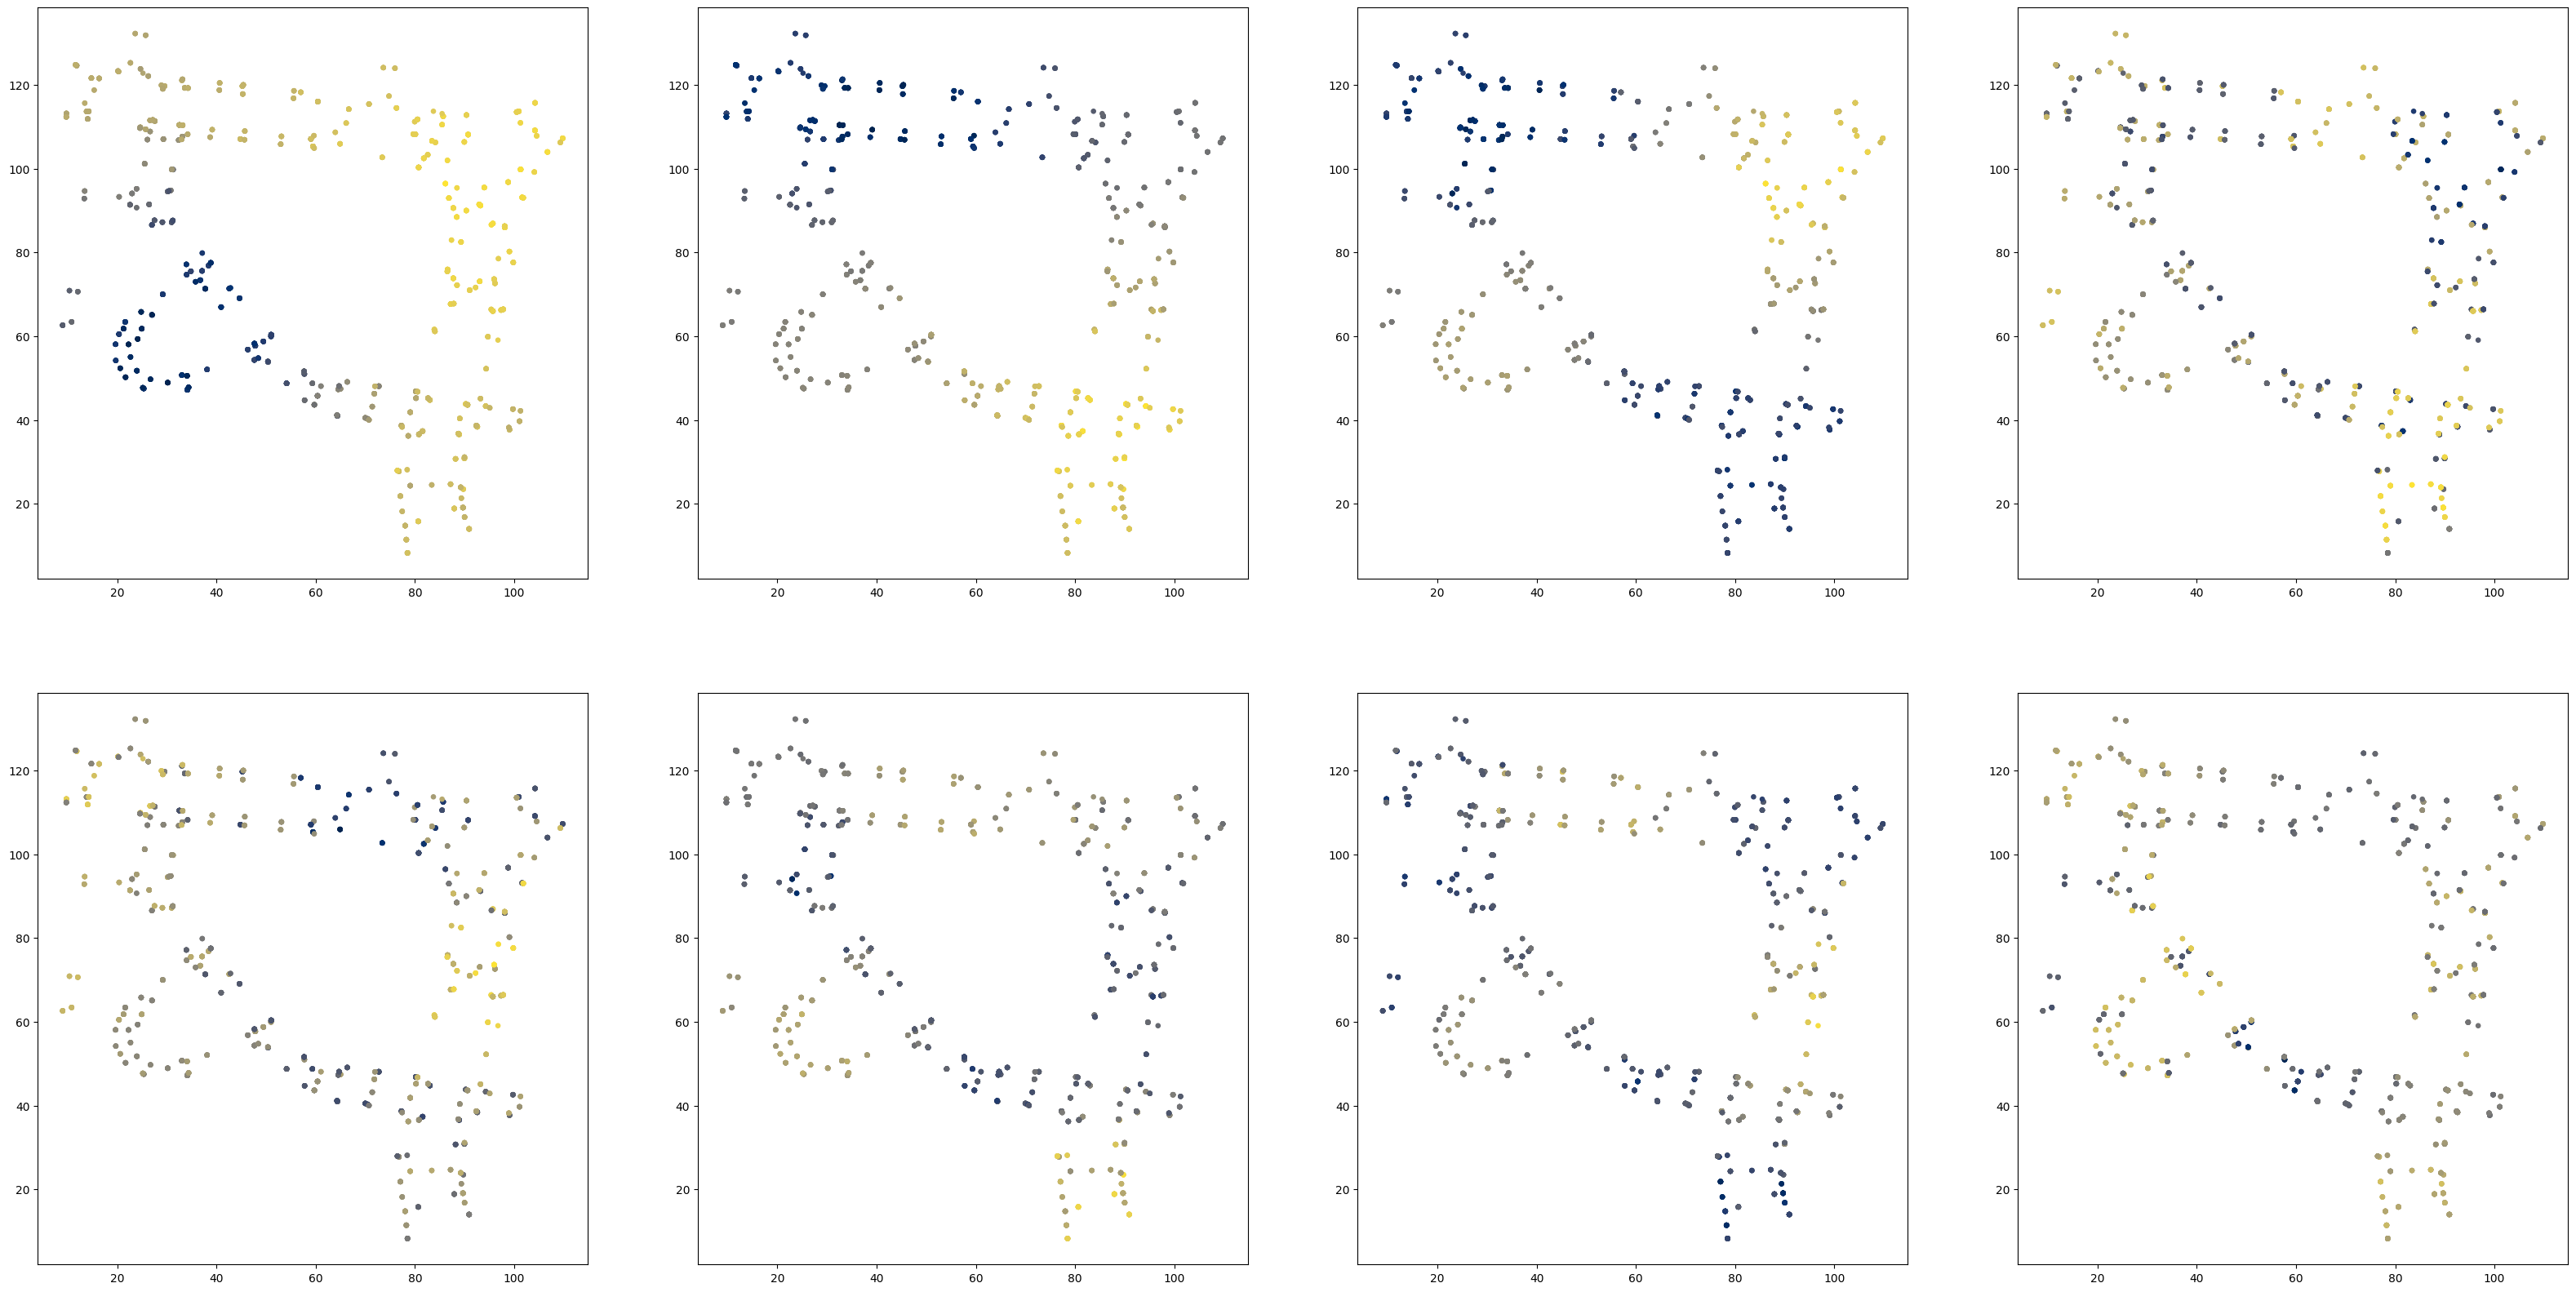

In [27]:
fig,axs = plt.subplots(2,4,figsize = (40,20))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(np.array(points_with_signals_df.loc[:,'x']),np.array(points_with_signals_df.loc[:,"y"]), c = signal_graph.embedding[:,i],s = 14,cmap = 'cividis')

In [20]:
locations = points_with_signals_df[["x", "y"]]
locations

,x,y
0,32.941338,106.977770
1,27.130260,111.622410
2,27.130260,111.622410
3,27.130260,111.622410
4,80.155380,46.839410
...,...,...
2263,57.750150,44.724094
2264,57.750150,44.724094
2265,64.689896,48.088620
2266,64.689896,48.088620


### sample points to create area graph

In [23]:
def sample_between_neighbors(
    df, 
    n_neighbors=2, 
    samples_per_neighbor=1, 
    noise_std=0.0, 
    random_state=None, 
    sample_range=(0.25, 1.25)  # ← controls how far along the line to sample
):
    """
    Samples new points along the line between each point and its neighbors.

    sample_range: (min_t, max_t) defines how far along the line to go
                  - (0, 1): between the two points
                  - (0.25, 1.25): beyond the line, more diverse
    """
    rng = np.random.default_rng(random_state)
    
    points = df[['x', 'y']].values
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(points)
    distances, indices = nbrs.kneighbors(points)
    
    new_points = []

    for i, neighbors in enumerate(indices):
        for j in range(1, n_neighbors + 1):  # skip self at index 0
            neighbor_idx = neighbors[j]
            p1 = points[i]
            p2 = points[neighbor_idx]
            direction = p2 - p1

            for _ in range(samples_per_neighbor):
                t = rng.uniform(*sample_range)
                sampled_point = p1 + t * direction
                if noise_std > 0:
                    sampled_point += rng.normal(0, noise_std, size=2)
                new_points.append(sampled_point)

    return np.array(new_points)


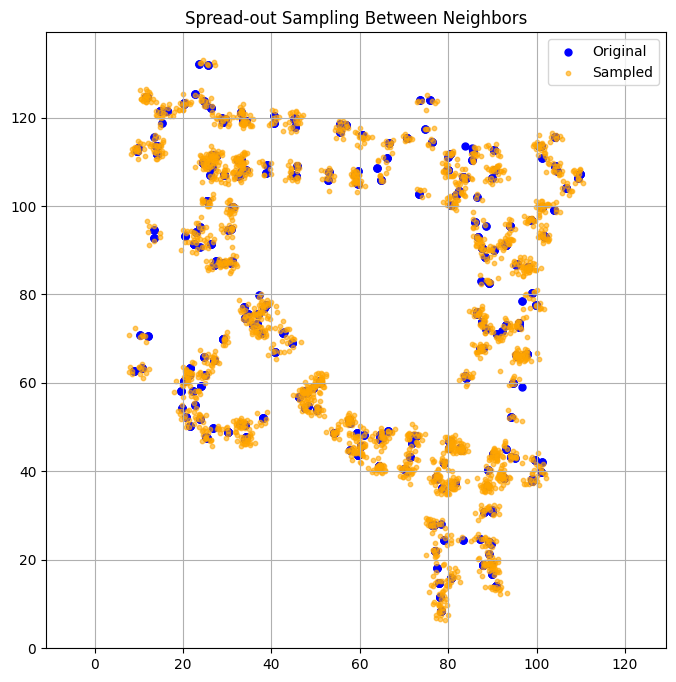

In [37]:
sampled_points_area = sample_between_neighbors(
    locations, 
    n_neighbors=1, 
    samples_per_neighbor=1, 
    noise_std=0.95,
    sample_range=(0.5, 5.5),
    random_state=42
)

plt.figure(figsize=(8, 8))
plt.scatter(locations['x'], locations['y'], c='blue', label='Original', s=25)
plt.scatter(sampled_points_area[:, 0], sampled_points_area[:, 1], c='orange', label='Sampled', s=10, alpha=0.6)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.title("Spread-out Sampling Between Neighbors")
plt.show()


In [44]:
sampled_points_area.head()

,x,y
0,31.953353,107.690699
1,25.276777,110.385339
2,26.829830,111.606449
3,27.965688,112.361312
4,81.226259,47.283544


In [39]:
sampled_points_area = pd.DataFrame(sampled_points_area, columns=["x","y"])
sampled_points_area

,x,y
0,31.953353,107.690699
1,25.276777,110.385339
2,26.829830,111.606449
3,27.965688,112.361312
4,81.226259,47.283544
...,...,...
2263,57.547242,46.463829
2264,58.622389,44.628611
2265,63.388545,48.654581
2266,66.385767,49.046268


In [48]:
#take just few of them. N_a is the number of points to create area graph
N_a_points = sampled_points_area.sample(n=50, random_state=42)
N_a_points

,x,y
188,79.539360,110.581482
1320,89.649742,35.214489
2221,98.684225,86.470360
1087,45.841931,57.326264
674,70.218032,39.183114
535,29.722543,47.603040
906,88.551739,37.894343
1441,72.945295,123.456290
1114,95.083063,43.154062
1875,32.065157,99.727668


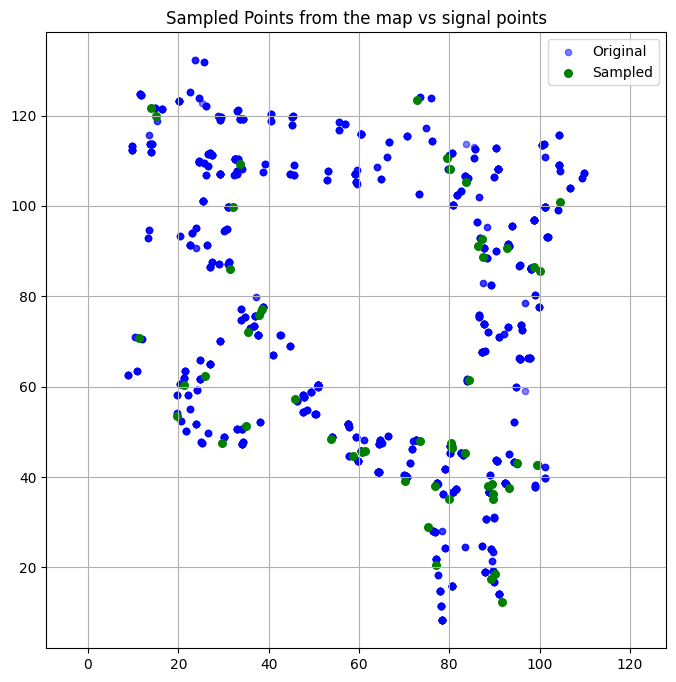

In [51]:
plt.figure(figsize=(8, 8))
plt.scatter(locations['x'], locations['y'], c='blue', label='Original', s=20, alpha=0.5)
plt.scatter(N_a_points.iloc[:, 0], N_a_points.iloc[:, 1], c='green', label='Sampled', s=30)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.title("Sampled Points from the map vs signal points")
plt.show()

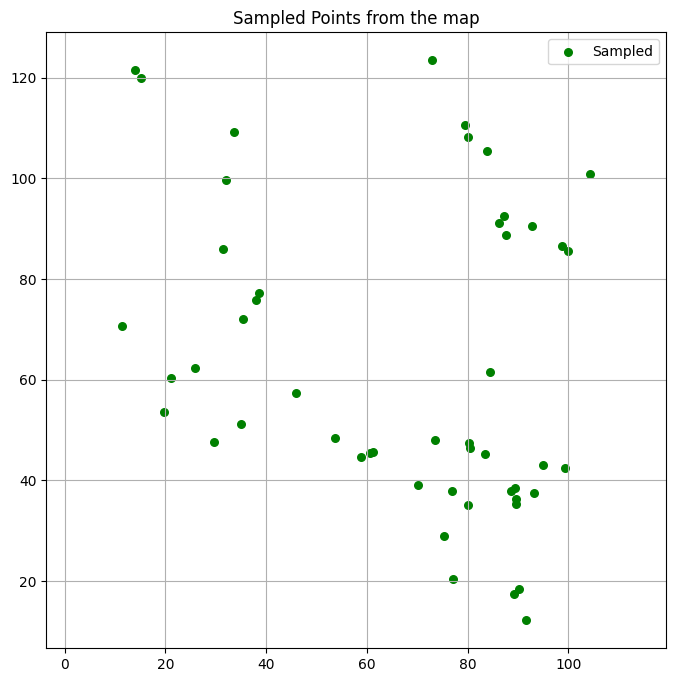

In [52]:
plt.figure(figsize=(8, 8))
plt.scatter(N_a_points.iloc[:, 0], N_a_points.iloc[:, 1], c='green', label='Sampled', s=30)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.title("Sampled Points from the map")
plt.show()

## Create Area Graph from the sampled points

In [ ]:
def create_dist_mat():
    layout_graph = PhysicalLayoutGraph(image_path, num_points=NUM_POINTS, embedding_dim=EIG_V_DIM, k=1)
    dist_matrix = compute_shortest_paths(layout_graph.G, layout_graph.random_points, layout_graph.circles)
    file_path_name = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl"
    with open(file_path_name, "wb") as f:
        pickle.dump({'dist_matrix': dist_matrix, 'layout_graph': layout_graph}, f)
    # pd.to_pickle(dist_matrix, fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_{NUM_POINTS}points_{NUM_RECIVERS}recivers.pkl")


def load_dist_mat():
    # path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\distance_matrix_1000points_9recivers.pkl"
    path = fr"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft_data_dist_mat.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
    dist_matrix = data['dist_matrix']
    layout_graph = data['layout_graph']

    if not os.path.exists(path):
        raise FileNotFoundError(f"Distance matrix file not found at {path}")
    return layout_graph, dist_matrix

In [ ]:
area_graph = PhysicalLayoutGraph(image_path, num_points=NUM_POINTS, embedding_dim=EIG_V_DIM, k=1)


# Copmute Embedding

In [16]:
area_graph._compute_embedding(2)

3


In [17]:
signal_graph._compute_embedding(2)

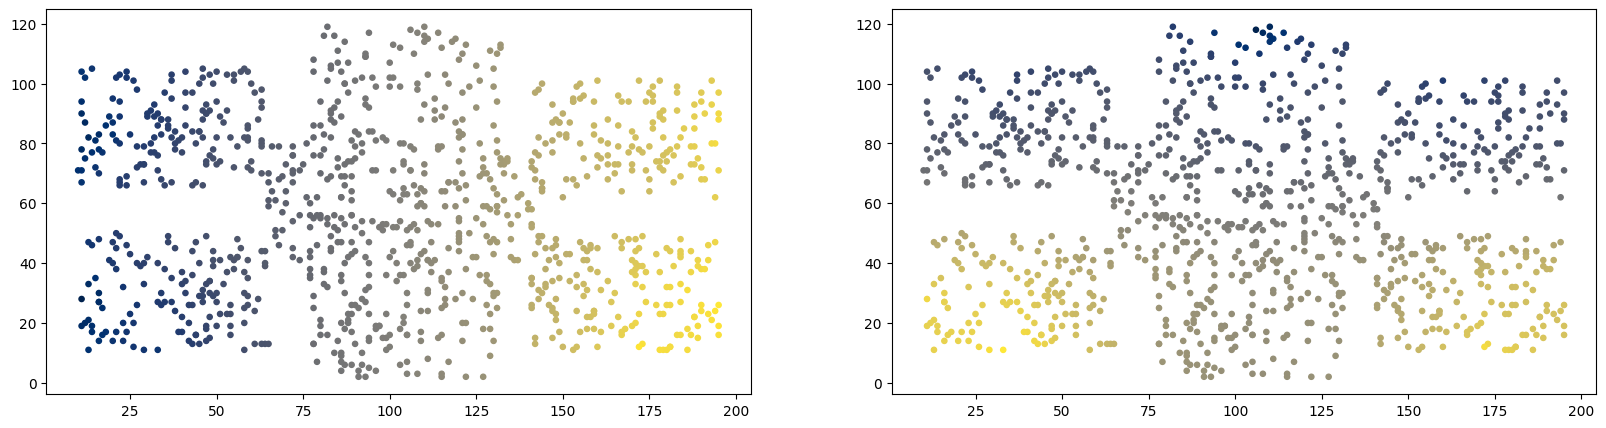

In [18]:
fig,axs = plt.subplots(1,EIG_V_DIM,figsize = (20,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(random_points_from_A[:,0],random_points_from_A[:,1],c = signal_graph.embedding[:,i],s = 14,cmap = 'cividis')

# SSL RUN

In [19]:
# Assuming you have already run the cells to create:
# - area_graph (PhysicalLayoutGraph built on all random_points)
# - signals (np.ndarray of signals for all random_points)
# - signal_graph (SignalGraph built on all signals)
# - points_with_signals_df (pd.DataFrame combining random_points and signals)


labeled_indices = [i for i in range(50)] 

# Initialize and fit the matcher using the pre-built graphs and labeled indices
matcher = MatcherSSL()
phi_s, centered_A, C, calib_phi_s = matcher.fit(area_graph, signal_graph, labeled_indices)
calib_phi_s
phi_s.shape

phi_S_dim :(50, 2), A_dim:(50, 2), C dim (2, 2), 
[[1582.82925699  -24.34234333]
 [ -45.43476872 -874.60836859]]


(50, 2)

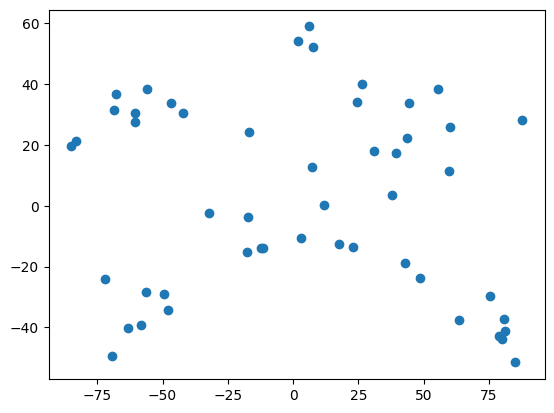

In [20]:
plt.scatter(phi_s @ C[:,0], phi_s @ C[:,1]) 


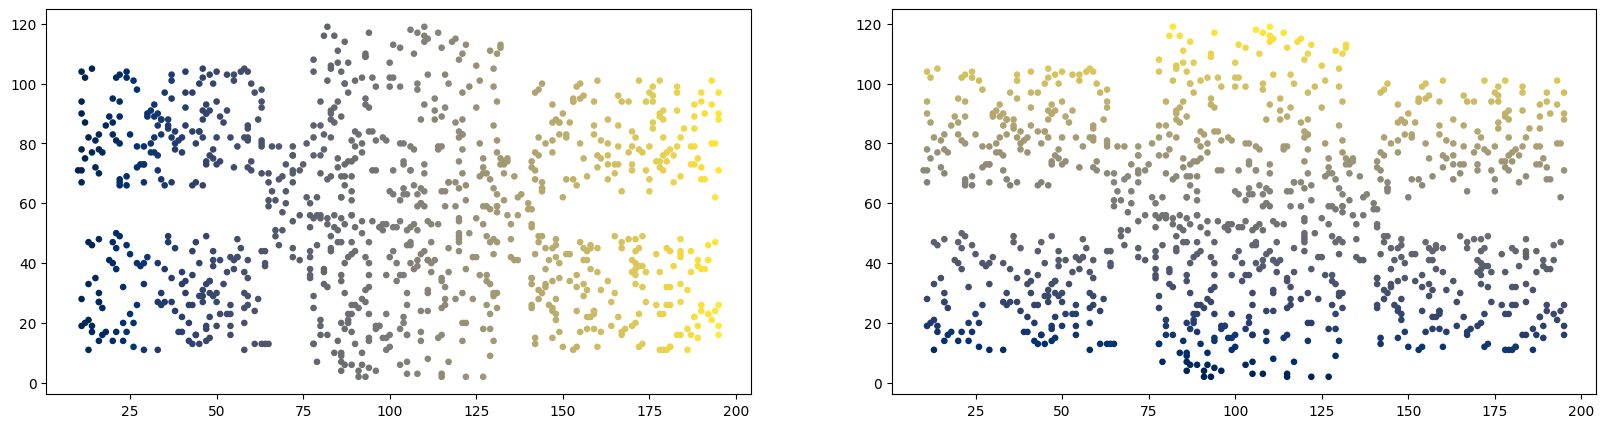

In [21]:
# EIGHEN VECTORS AREA
fig,axs = plt.subplots(1,EIG_V_DIM,figsize = (20,5))
for i,ax in enumerate(axs.flatten()):
    ax.scatter(random_points_from_A[:,0],random_points_from_A[:,1],c = area_graph.embedding[:,i],s = 14,cmap = 'cividis')

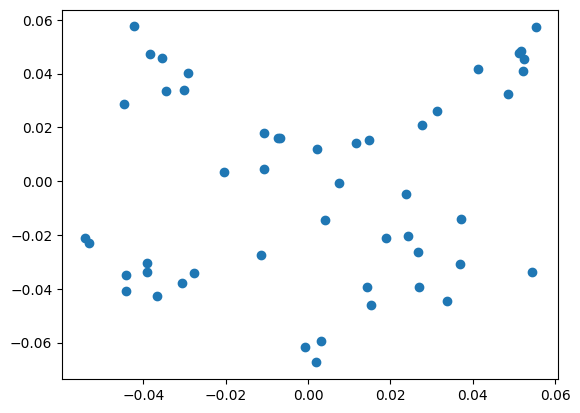

In [22]:
plt.scatter(phi_s[:,0], phi_s[:,1]) 


In [25]:
# Define validation indices (e.g., indices from 20 to 29)
# Make sure these indices are not in labeled_indices
validation_indices = list(range(100, 150))

# Important: Add a check to ensure validation_indices do not overlap with labeled_indices
if any(i in labeled_indices for i in validation_indices):
    raise ValueError("Validation indices overlap with labeled indices.")

# Extract signal data and true layout locations for validation points
validation_data = points_with_signals_df.iloc[validation_indices].copy()
validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
validation_true_real_locations = validation_data[['x', 'y']].values
validation_signal_data.shape
# Predict locations for the validation signal data
predicted_locations_validation_SSL = matcher.predict(validation_indices)


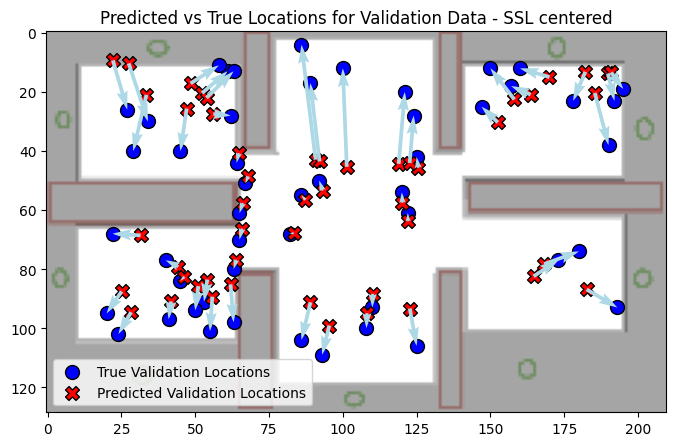

In [26]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
plt.imshow(area_graph.polygon_mask, cmap='gray', alpha=0.5)
plt.imshow(area_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations[:, 0], validation_true_real_locations[:, 1], color='blue', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_SSL[:, 0], predicted_locations_validation_SSL[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations[:, 0] - predicted_locations_validation_SSL[:, 0]
dy = validation_true_real_locations[:, 1] - predicted_locations_validation_SSL[:, 1]

# Draw arrows
plt.quiver(predicted_locations_validation_SSL[:, 0], predicted_locations_validation_SSL[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightblue', width=0.006)

plt.legend()
plt.title("Predicted vs True Locations for Validation Data - SSL centered")
plt.show()

# Manifold Matching

In [27]:
class ManifoldMatcher:
    def __init__(self, layout_graph= None, signal_graph = None):
        self.fitted = False
        self.layout_graph = layout_graph
        self.signal_graph = signal_graph
        self.aligned_signal_embedding = None
        self.labeled_indices = None 

    def fit(self, labeled_indices):
        """
        Calibrate layout to signal space using SSL-style least squares.
        """

        # phi_A = layout_embedding[labeled_indices]
        phi_S = self.signal_graph.embedding[labeled_indices]
        phi_A = self.layout_graph.embedding[labeled_indices]
        print(f"phi_S_dim :{phi_S.shape}, A_emb_dim:{self.layout_graph.embedding[labeled_indices].shape}, ")
        self.C, _, _, _ = np.linalg.lstsq( phi_S, phi_A, rcond=None)

        self.calibrated_phi_s = phi_S  @ self.C
        self.fitted = True
        return phi_S, self.C, self.calibrated_phi_s

    def predict(self, validation_indices):
        """
        Predict layout locations for new signal vectors (not embeddings).
        Uses 1-NN matching in calibrated spectral space.
        """
        if not self.fitted:
            raise ValueError("Must call .fit() before .predict()")
        # self.calibrated_phi_s = self.calibrated_phi_s + self.A_mean
        
        self.calibrated_phi_s =self.signal_graph.embedding[validation_indices] @ self.C
        self.calibrated_all_points_phi_s = self.signal_graph.embedding @ self.C # TODO WRITE ABOUT IT 
        D = cdist(self.calibrated_phi_s, self.layout_graph.embedding)
        min_idx = np.argmin(D, axis=1)
        return self.layout_graph.get_points()[min_idx]


In [28]:
labeled_indices = [i for i in range(50)] 

In [29]:
manifold = ManifoldMatcher(area_graph, signal_graph)

In [30]:
manifold.fit(labeled_indices)

phi_S_dim :(50, 2), A_emb_dim:(50, 2), 


(array([[ 0.00747298, -0.00064298],
        [-0.02916987,  0.04008663],
        [ 0.03694575, -0.03072567],
        [ 0.01492378,  0.01524878],
        [ 0.05124649,  0.04751239],
        [ 0.02370068, -0.0046841 ],
        [-0.03019365,  0.03388832],
        [ 0.03365444, -0.0446194 ],
        [ 0.00229217,  0.01213511],
        [ 0.01437031, -0.03940297],
        [-0.02030243,  0.00336319],
        [ 0.02768762,  0.02089864],
        [-0.00065206, -0.0618055 ],
        [-0.00682309,  0.01593802],
        [-0.03664136, -0.04273834],
        [-0.05307397, -0.02293064],
        [ 0.00308297, -0.0596075 ],
        [ 0.03720468, -0.01424016],
        [-0.04430635, -0.03470713],
        [-0.03544906,  0.04565556],
        [-0.0277192 , -0.03406012],
        [-0.05424174, -0.02106595],
        [-0.0390236 , -0.03049565],
        [-0.01074953,  0.00457977],
        [ 0.03133022,  0.02627889],
        [-0.01056723,  0.01782926],
        [-0.03848732,  0.04715868],
        [ 0.02692702, -0.039

In [31]:
manifold.calibrated_phi_s.shape

(50, 2)

In [32]:
area_graph.get_points()[0]

array([114,  53])

In [33]:
pd.DataFrame(data = area_graph.get_points())

,0,1
0,114,53
1,64,13
2,169,77
3,129,18
4,177,26
...,...,...
995,78,82
996,16,83
997,50,30
998,29,73


In [34]:
# Define validation indices (e.g., indices from 20 to 29)
# Make sure these indices are not in labeled_indices
validation_indices = list(range(100, 150))

# Important: Add a check to ensure validation_indices do not overlap with labeled_indices
if any(i in labeled_indices for i in validation_indices):
    raise ValueError("Validation indices overlap with labeled indices.")

# Extract signal data and true layout locations for validation points
validation_data = pd.DataFrame(data = area_graph.get_points(),columns=['x', 'y']).iloc[validation_indices].copy()
validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
validation_true_real_locations = validation_data[['x', 'y']].values
validation_signal_data.shape

# Predict locations for the validation signal data
predicted_locations_validation_manifold = manifold.predict(validation_indices)


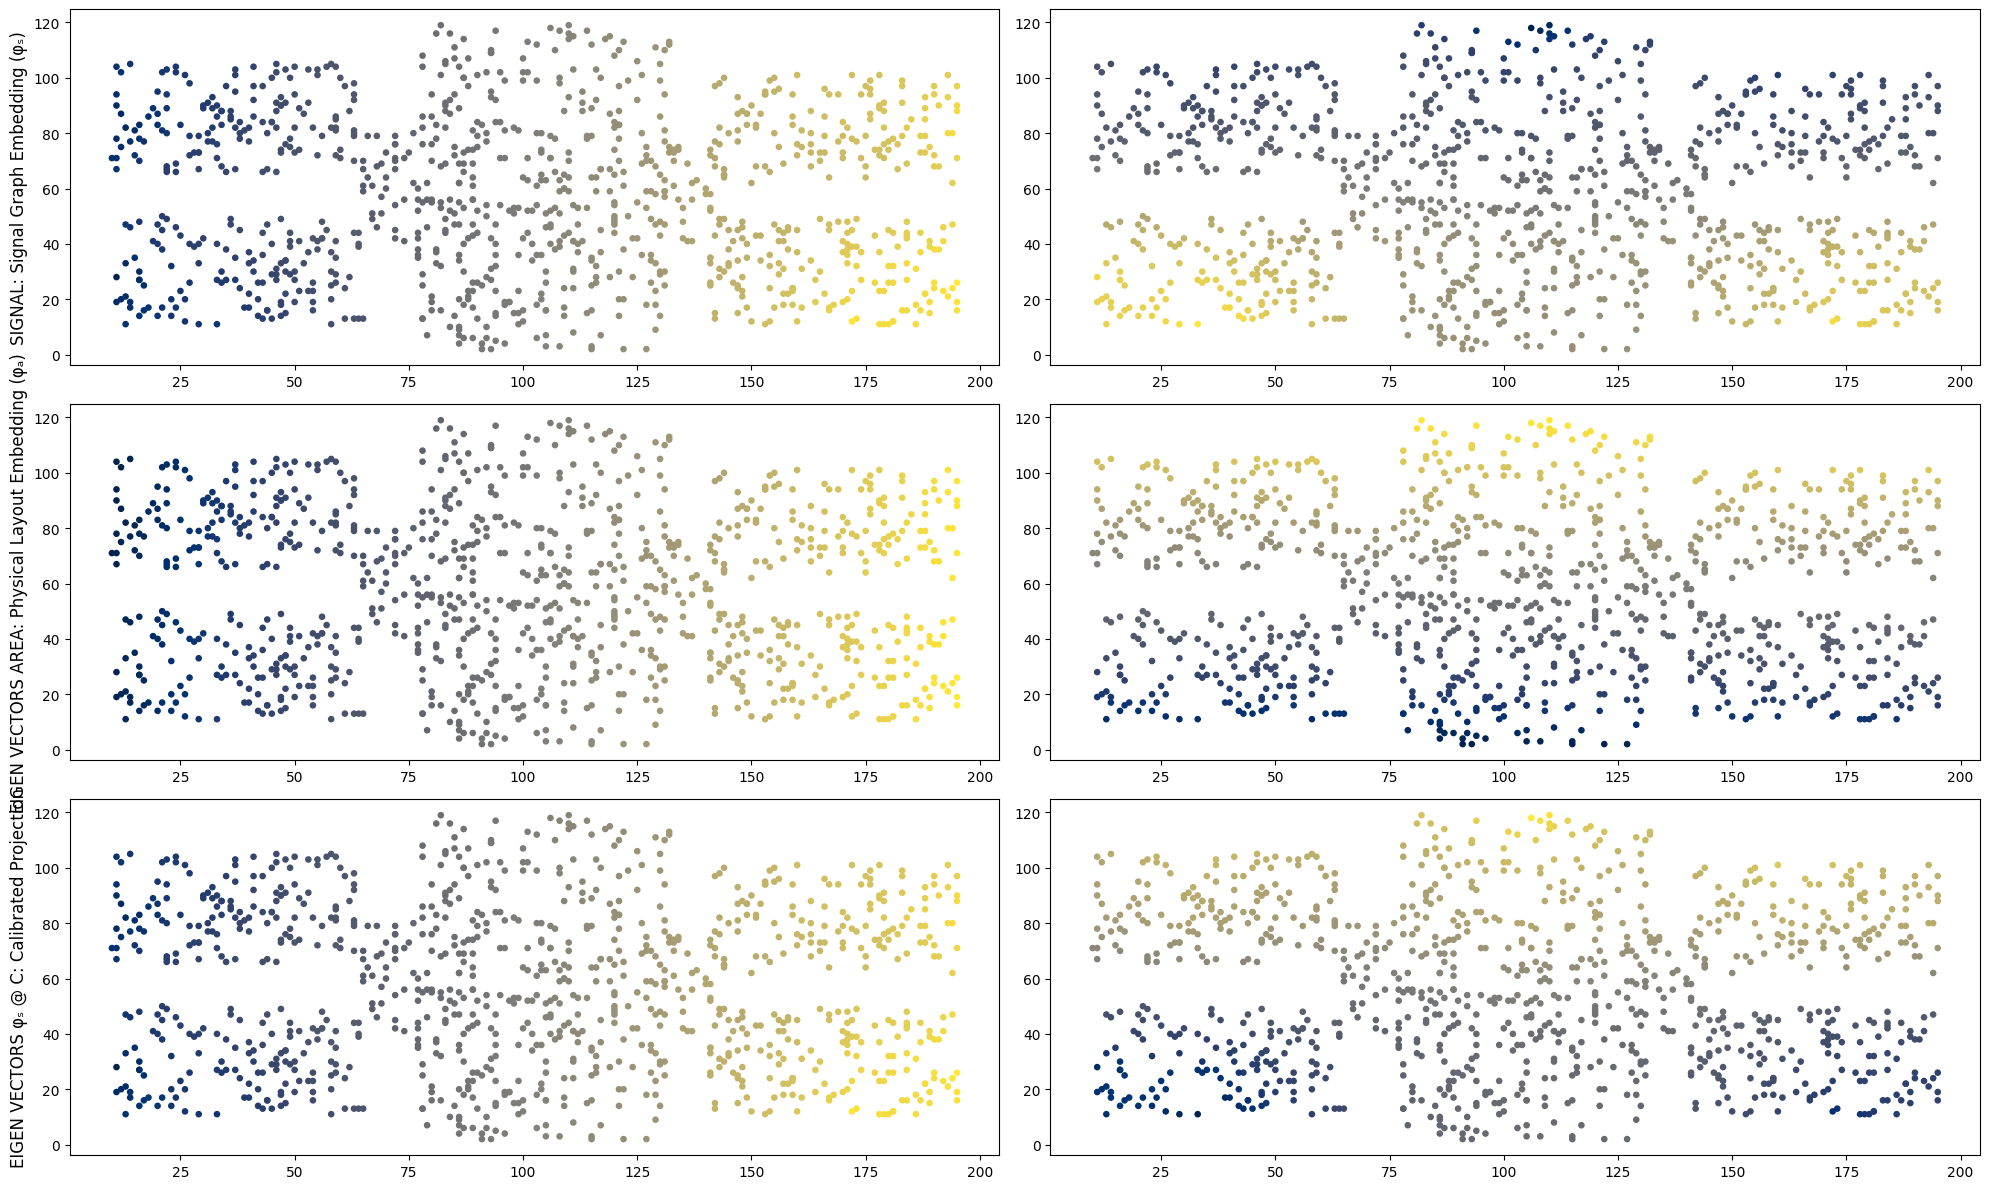

In [35]:
fig, axs = plt.subplots(3, EIG_V_DIM, figsize=(20, 12))

# Row titles
row_titles = [
    "SIGNAL: Signal Graph Embedding (φₛ)",
    "EIGEN VECTORS AREA: Physical Layout Embedding (φₐ)",
    "EIGEN VECTORS φₛ @ C: Calibrated Projection"
]

# Plot row 1: Signal graph
for i, ax in enumerate(axs[0]):
    ax.scatter(random_points_from_A[:, 0], random_points_from_A[:, 1],
               c=signal_graph.embedding[:, i], s=14, cmap='cividis')
    if i == 0:
        ax.set_ylabel(row_titles[0], fontsize=12)

# Plot row 2: Area graph
for i, ax in enumerate(axs[1]):
    ax.scatter(random_points_from_A[:, 0], random_points_from_A[:, 1],
               c=area_graph.get_embedding()[:, i], s=14, cmap='cividis')
    if i == 0:
        ax.set_ylabel(row_titles[1], fontsize=12)

# Plot row 3: Calibrated projection
for i, ax in enumerate(axs[2]):
    ax.scatter(random_points_from_A[:, 0], random_points_from_A[:, 1],
               c=manifold.calibrated_all_points_phi_s[:, i], s=14, cmap='cividis')
    if i == 0:
        ax.set_ylabel(row_titles[2], fontsize=12)

plt.tight_layout()
plt.show()


In [37]:
train_data_sig = points_with_signals_df[['x', 'y']].iloc[labeled_indices]

In [38]:
predicted_locations_validation_manifold[labeled_indices]

array([[189,  15],
       [ 90,  44],
       [ 29,  11],
       [189,  15],
       [ 22,  89],
       [120,  44],
       [101,  44],
       [ 26,  12],
       [ 46,  27],
       [ 54,  19],
       [ 63,  79],
       [181,  12],
       [ 86,  89],
       [ 65,  67],
       [161,  81],
       [ 41,  92],
       [186,  18],
       [ 89,  56],
       [110,  93],
       [170,  79],
       [ 92,  54],
       [ 44,  80],
       [154,  32],
       [125,  92],
       [ 54,  26],
       [ 54,  82],
       [ 59,  85],
       [ 54,  23],
       [179,  88],
       [ 46,  82],
       [ 65,  59],
       [ 40,  22],
       [ 67,  49],
       [167,  16],
       [ 90,  44],
       [120,  65],
       [164,  19],
       [ 53,  91],
       [ 32,  93],
       [ 52,  87],
       [ 47,  18],
       [109,  88],
       [ 96,  99],
       [129,  47],
       [120,  44],
       [ 34,  68],
       [119,  59],
       [158,  22],
       [ 64,  40],
       [ 82,  68]])

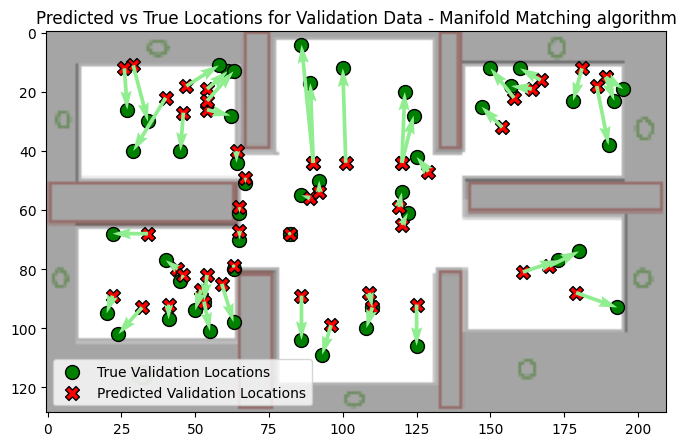

In [39]:
# Plot the predicted and true locations for the validation data on the layout
plt.figure(figsize=(8, 8))
plt.imshow(area_graph.polygon_mask, cmap='gray', alpha=0.5)
plt.imshow(area_graph.image, alpha=0.3)

# Plot the true locations of the validation points
plt.scatter(validation_true_real_locations[:, 0], validation_true_real_locations[:, 1], color='green', s=100, label="True Validation Locations", marker='o', edgecolor='black')

# Plot the predicted locations of the validation points
plt.scatter(predicted_locations_validation_manifold[:, 0], predicted_locations_validation_manifold[:, 1], color='red', s=100, label="Predicted Validation Locations", marker='X', edgecolor='black')

# Compute deltas
dx = validation_true_real_locations[:, 0] - predicted_locations_validation_manifold[:, 0]
dy = validation_true_real_locations[:, 1] - predicted_locations_validation_manifold[:, 1]

# Draw arrows
plt.quiver(predicted_locations_validation_manifold[:, 0], predicted_locations_validation_manifold[:, 1], dx, dy, angles='xy', scale_units='xy', scale=1, color='lightgreen', width=0.006)


plt.legend()
plt.title("Predicted vs True Locations for Validation Data - Manifold Matching algorithm")
plt.show()

In [40]:
np.linalg.norm(predicted_locations_validation_manifold- validation_true_real_locations, axis=1).mean()

np.float64(10.90602778500187)

# Auto Encoder 

In [19]:
class SignalAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], bottleneck_dim=2):
        super().__init__()
        # Encoder
        layers = []
        last_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.ReLU())
            last_dim = h
        layers.append(nn.Linear(last_dim, bottleneck_dim))  # bottleneck
        self.encoder = nn.Sequential(*layers)

        # Decoder
        decoder_layers = []
        last_dim = bottleneck_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(last_dim, h))
            decoder_layers.append(nn.ReLU())
            last_dim = h
        decoder_layers.append(nn.Linear(last_dim, input_dim))  # output
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

In [26]:
class AutoencoderMatcher:
    def __init__(self, signal_graph, layout_graph, device='cpu'):
        self.signal_graph = signal_graph
        self.layout_graph = layout_graph
        self.device = device

    def fit(self, labeled_indices, epochs=200, lr=1e-3, alpha=1.0):
        """
        Train autoencoder with combined reconstruction and alignment loss.
        alpha: weight for alignment loss
        """
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        Y = torch.tensor(self.layout_graph.get_points(), dtype=torch.float32).to(self.device)
        y_labeled = Y[labeled_indices]
        x_labeled = X[labeled_indices]

        self.model = SignalAutoencoder(X.shape[1]).to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        for epoch in range(epochs):
            optimizer.zero_grad()
            x_hat, z = self.model(X)
            z_labeled = z[labeled_indices]

            recon_loss = loss_fn(x_hat, X)
            align_loss = loss_fn(z_labeled, y_labeled[:, :2])  # target is 2D projection
            loss = recon_loss + alpha * align_loss
            loss.backward()
            optimizer.step()

    def predict(self, validation_indices):
        """
        Returns 2D latent codes for given signal validation points
        """
        self.model.eval()
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            z = self.model.encoder(X)
        return z[validation_indices].cpu().numpy()


In [33]:
matcher = AutoencoderMatcher(signal_graph, area_graph)

In [34]:
labeled_indices_fit = [i for i in range(50)] 
matcher.fit(labeled_indices=labeled_indices_fit, epochs=300, alpha=10.0)


In [35]:
validation_indices = list(range(100, 150))
pred_2d = matcher.predict(validation_indices=validation_indices)

In [36]:
validation_data = pd.DataFrame(data = area_graph.get_points(),columns=['x', 'y']).iloc[validation_indices].copy()
validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
validation_true_real_locations_AE = validation_data[['x', 'y']].values

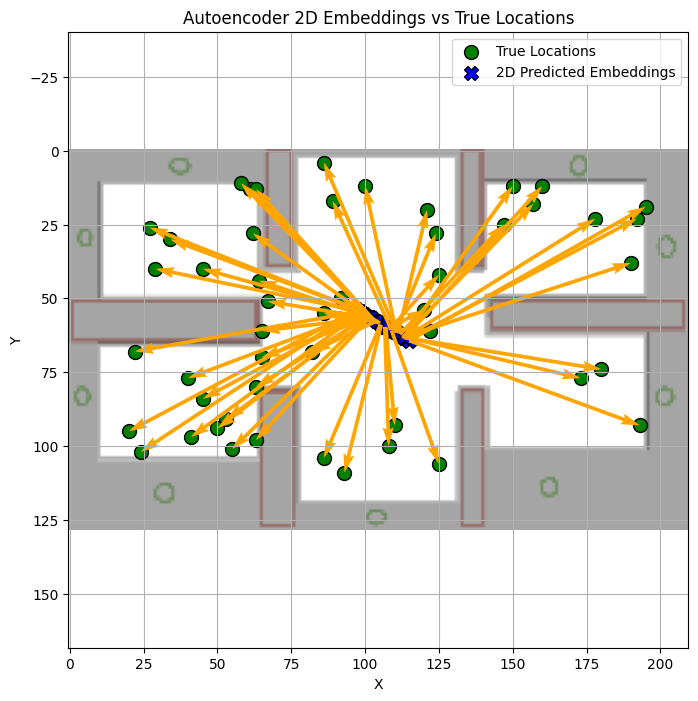

In [38]:
# Plot the 2D predictions vs true real locations
plt.figure(figsize=(8, 8))
plt.imshow(area_graph.polygon_mask, cmap='gray', alpha=0.5)
plt.imshow(area_graph.image, alpha=0.3)

# Plot the true real-world locations
plt.scatter(validation_true_real_locations_AE[:, 0], validation_true_real_locations_AE[:, 1],
            color='green', s=100, label="True Locations", marker='o', edgecolor='black')

# Plot the 2D predictions from the autoencoder
plt.scatter(pred_2d[:, 0], pred_2d[:, 1],
            color='blue', s=100, label="2D Predicted Embeddings", marker='X', edgecolor='black')

# Compute the delta vectors
dx = validation_true_real_locations_AE[:, 0] - pred_2d[:, 0]
dy = validation_true_real_locations_AE[:, 1] - pred_2d[:, 1]

# Draw arrows from prediction to ground truth
plt.quiver(pred_2d[:, 0], pred_2d[:, 1], dx, dy,
           angles='xy', scale_units='xy', scale=1,
           color='orange', width=0.006)

plt.legend()
plt.title("Autoencoder 2D Embeddings vs True Locations")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn

class SignalAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64]):
        super(SignalAutoencoder, self).__init__()

        # Encoder to 2D
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], 2)
        )

        # Decoder from 2D back to original input
        self.decoder = nn.Sequential(
            nn.Linear(2, hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class AutoencoderMatcher:
    def __init__(self, signal_graph, layout_graph):
        self.signal_graph = signal_graph
        self.layout_graph = layout_graph
        self.device = torch.device('cpu')  # Force CPU usage

    def fit(self, labeled_indices, epochs=200, lr=1e-3, alpha=1.0):
        """
        Trains autoencoder using:
        - Reconstruction loss on all data
        - Alignment loss between 2D latent codes and real 2D locations for labeled points
        """
        # Full signal data (N x D)
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        Y = torch.tensor(self.layout_graph.get_points(), dtype=torch.float32).to(self.device)

        x_labeled = X[labeled_indices]
        y_labeled = Y[labeled_indices, :2]  # only 2D locations for alignment

        self.model = SignalAutoencoder(input_dim=X.shape[1]).to(self.device)
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        for epoch in range(epochs):
            self.model.train()
            optimizer.zero_grad()

            x_hat, z = self.model(X)
            z_labeled = z[labeled_indices]

            recon_loss = loss_fn(x_hat, X)
            align_loss = loss_fn(z_labeled, y_labeled)
            total_loss = recon_loss + alpha * align_loss

            total_loss.backward()
            optimizer.step()

            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch:3d} | Recon: {recon_loss.item():.4f} | Align: {align_loss.item():.4f} | Total: {total_loss.item():.4f}")

    def predict(self, validation_indices):
        """
        Returns 2D latent codes (z) for given signal validation points
        """
        self.model.eval()
        X = torch.tensor(self.signal_graph.signal_data, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            z = self.model.encoder(X)
        return z[validation_indices].cpu().numpy()




In [46]:
matcher = AutoencoderMatcher(signal_graph, area_graph)
matcher.fit(labeled_indices=labeled_indices_fit, epochs=200, lr=1e-3, alpha=0.5)
pred_2d = matcher.predict(validation_indices=validation_indices)

Epoch   0 | Recon Loss: 92.1456 | Align Loss: 9255.0645 | Total: 4719.6777
Epoch  10 | Recon Loss: 77.4243 | Align Loss: 8420.0283 | Total: 4287.4385
Epoch  20 | Recon Loss: 19.3381 | Align Loss: 7316.1558 | Total: 3677.4160
Epoch  30 | Recon Loss: 40.3203 | Align Loss: 5677.8198 | Total: 2879.2302
Epoch  40 | Recon Loss: 10.2404 | Align Loss: 3741.8848 | Total: 1881.1827
Epoch  50 | Recon Loss: 3.7092 | Align Loss: 2258.1868 | Total: 1132.8026
Epoch  60 | Recon Loss: 1.5201 | Align Loss: 2030.3655 | Total: 1016.7029
Epoch  70 | Recon Loss: 1.4025 | Align Loss: 1967.6683 | Total: 985.2366
Epoch  80 | Recon Loss: 1.2002 | Align Loss: 1897.3187 | Total: 949.8596
Epoch  90 | Recon Loss: 1.2191 | Align Loss: 1880.3500 | Total: 941.3941
Epoch 100 | Recon Loss: 1.1886 | Align Loss: 1845.5557 | Total: 923.9664
Epoch 110 | Recon Loss: 1.2046 | Align Loss: 1819.7561 | Total: 911.0827
Epoch 120 | Recon Loss: 1.2336 | Align Loss: 1791.3560 | Total: 896.9116
Epoch 130 | Recon Loss: 1.2675 | Align 

In [47]:
validation_data = pd.DataFrame(data = area_graph.get_points(),columns=['x', 'y']).iloc[validation_indices].copy()
validation_signal_data = validation_data.drop(['x', 'y'], axis=1).values
validation_true_real_locations_AE = validation_data[['x', 'y']].values

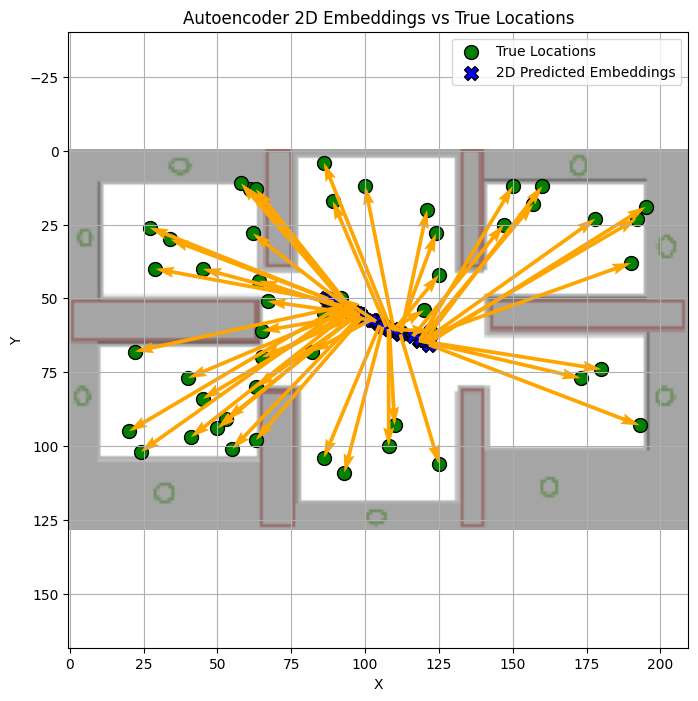

In [48]:
# Plot the 2D predictions vs true real locations
plt.figure(figsize=(8, 8))
plt.imshow(area_graph.polygon_mask, cmap='gray', alpha=0.5)
plt.imshow(area_graph.image, alpha=0.3)

# Plot the true real-world locations
plt.scatter(validation_true_real_locations_AE[:, 0], validation_true_real_locations_AE[:, 1],
            color='green', s=100, label="True Locations", marker='o', edgecolor='black')

# Plot the 2D predictions from the autoencoder
plt.scatter(pred_2d[:, 0], pred_2d[:, 1],
            color='blue', s=100, label="2D Predicted Embeddings", marker='X', edgecolor='black')

# Compute the delta vectors
dx = validation_true_real_locations_AE[:, 0] - pred_2d[:, 0]
dy = validation_true_real_locations_AE[:, 1] - pred_2d[:, 1]

# Draw arrows from prediction to ground truth
plt.quiver(pred_2d[:, 0], pred_2d[:, 1], dx, dy,
           angles='xy', scale_units='xy', scale=1,
           color='orange', width=0.006)

plt.legend()
plt.title("Autoencoder 2D Embeddings vs True Locations")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)
plt.show()


# Cross Validation

In [41]:
def run_loocv_gridsearch(layout_graph, signal_graph, labeled_indices, l_dims, s_dims):
    """
    Run LOOCV across grid of layout and signal embedding dimensions.

    Args:
        layout_graph: PhysicalLayoutGraph instance
        signal_graph: SignalGraph instance
        labeled_indices: list of shared indices used for CV
        l_dims: list of layout embedding dimensions to try
        s_dims: list of signal embedding dimensions to try

    Returns:
        error_matrix: 2D array of shape (len(l_dims), len(s_dims))
        best_params: tuple (best_l_dim, best_s_dim)
    """
    error_matrix = np.zeros((len(l_dims), len(s_dims)))

    for i, l_dim in enumerate(l_dims):
        layout_graph._compute_embedding(l_dim)

        for j, s_dim in enumerate(s_dims):
            signal_graph._compute_embedding(s_dim)

            errors = []
            for k in range(len(labeled_indices)):
                val_idx = labeled_indices[k]
                train_idx = labeled_indices[:k] + labeled_indices[k+1:]

                matcher = ManifoldMatcher(layout_graph=layout_graph, signal_graph=signal_graph)
                matcher.fit(train_idx)
                pred = matcher.predict([val_idx])[0]
                true = layout_graph.get_points()[val_idx]
                error = np.linalg.norm(pred - true)
                errors.append(error)

            mean_error = np.mean(errors)
            error_matrix[i, j] = mean_error
            print(f"l={l_dim}, s={s_dim} → LOOCV error: {mean_error:.2f}")

    # Find best parameters
    best_idx = np.unravel_index(np.argmin(error_matrix), error_matrix.shape)
    best_l = l_dims[best_idx[0]]
    best_s = s_dims[best_idx[1]]

    return error_matrix, (best_l, best_s)


In [42]:
l_dims = [2,3, 4,5,6]
s_dims = [2,3,4,5,6]
shared_indices = list(range(60)) 

error_matrix, best_params = run_loocv_gridsearch(area_graph, signal_graph, shared_indices, l_dims, s_dims)
print("Best parameters:", best_params)


3
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2), 
phi_S_dim :(59, 2), A_emb_dim:(59, 2),

In [43]:
def plot_cv_heatmap(error_matrix, l_dims, s_dims):
    # Convert to numpy arrays for indexing
    l_dims = np.array(l_dims)
    s_dims = np.array(s_dims)

    # Sort by l_dims descending (row-wise)
    sort_idx = np.argsort(l_dims)[::-1]
    error_matrix_sorted = error_matrix[sort_idx, :]
    l_dims_sorted = l_dims[sort_idx]

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        error_matrix_sorted,
        annot=True, fmt=".2f",
        xticklabels=s_dims,
        yticklabels=l_dims_sorted,
        cmap="viridis"
    )
    ax.set_xlabel("Signal Embedding Dimension (s_dim)")
    ax.set_ylabel("Layout Embedding Dimension (l_dim)")
    ax.set_title("LOOCV Error Heatmap")
    plt.tight_layout()
    plt.show()


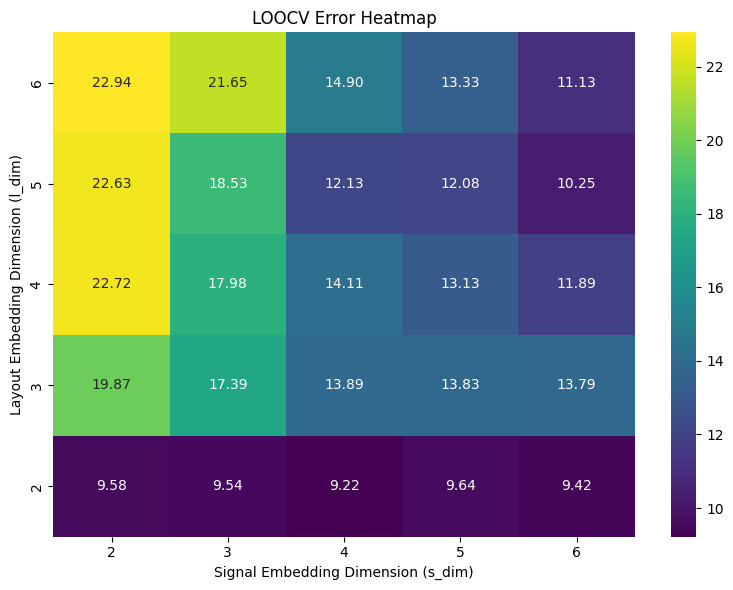

In [44]:
plot_cv_heatmap(error_matrix, l_dims, s_dims)

In [45]:
def run_cv_fixed_train_size(layout_graph, signal_graph, shared_indices, l_dims, s_dims, train_size=20, val_sizes=[30, 50, 80, 100]):
    """
    Perform cross-validation with fixed training size and varying validation sizes.

    Returns:
        results: list of dicts, each with:
            {
                'val_size': int,
                'best_error': float,
                'best_l': int,
                'best_s': int,
                'error_matrix': np.ndarray of shape (len(l_dims), len(s_dims))
            }
    """
    np.random.seed(42)
    shared_indices = np.array(shared_indices)
    results = []

    for val_size in val_sizes:
        if train_size + val_size > len(shared_indices):
            raise ValueError("train_size + val_size exceeds number of available points")

        # Subsample training + validation indices
        chosen_indices = np.random.choice(shared_indices, train_size + val_size, replace=False)
        train_idx = chosen_indices[:train_size]
        val_idx = chosen_indices[train_size:]

        error_matrix = np.zeros((len(l_dims), len(s_dims)))

        for i, l_dim in enumerate(l_dims):
            for j, s_dim in enumerate(s_dims):
                # Set embeddings
                layout_graph._compute_embedding(l_dim)
                signal_graph._compute_embedding(s_dim)

                matcher = ManifoldMatcher(layout_graph, signal_graph)
                matcher.fit(train_idx)
                pred = matcher.predict( val_idx)
                true = layout_graph.get_points()[val_idx]
                error = np.linalg.norm(pred - true, axis=1).mean()
                error_matrix[i, j] = error

        best_i, best_j = np.unravel_index(np.argmin(error_matrix), error_matrix.shape)
        results.append({
            'val_size': val_size,
            'best_error': error_matrix[best_i, best_j],
            'best_l': l_dims[best_i],
            'best_s': s_dims[best_j],
            'error_matrix': error_matrix
        })

    return results


In [46]:
import matplotlib.pyplot as plt

def plot_cv_vs_val_size(results):
    """
    Plot Best LOOCV Error vs Validation Size
    """
    val_sizes = [r['val_size'] for r in results]
    best_errors = [r['best_error'] for r in results]

    plt.figure(figsize=(8, 5))
    plt.plot(val_sizes, best_errors, marker='o')
    plt.title("Best LOOCV Error vs Validation Set Size")
    plt.xlabel("Validation Set Size")
    plt.ylabel("Mean LOOCV Error")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [47]:
l_dims = [2, 3, 4]
s_dims = [2, 3, 4]
val_sizes = [20,50,100,200]
shared_indices = list(range(NUM_POINTS)) 
results = run_cv_fixed_train_size(area_graph, signal_graph, shared_indices, l_dims, s_dims, train_size=20, val_sizes=val_sizes)


3
phi_S_dim :(20, 2), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 3), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 4), A_emb_dim:(20, 2), 
4
phi_S_dim :(20, 2), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 3), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 4), A_emb_dim:(20, 3), 
5
phi_S_dim :(20, 2), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 3), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 4), A_emb_dim:(20, 4), 
3
phi_S_dim :(20, 2), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 3), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 4), A_emb_dim:(20, 2), 
4
phi_S_dim :(20, 2), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 3), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 4), A_emb_dim:(20, 3), 
5
phi_S_dim :(20, 2), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 3), A_emb_dim:(20, 4), 
5
phi_S_dim :(20, 4), A_emb_dim:(20, 4), 
3
phi_S_dim :(20, 2), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 3), A_emb_dim:(20, 2), 
3
phi_S_dim :(20, 4), A_emb_dim:(20, 2), 
4
phi_S_dim :(20, 2), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 3), A_emb_dim:(20, 3), 
4
phi_S_dim :(20, 4), A_emb_dim:(2

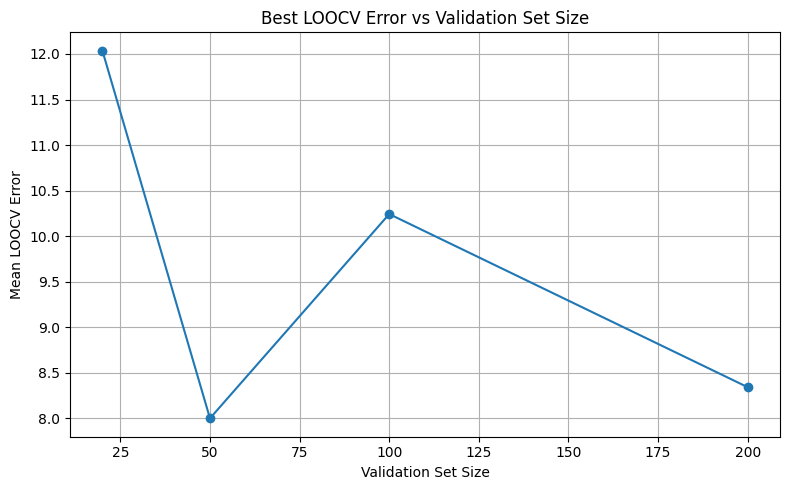

In [48]:
plot_cv_vs_val_size(results)

In [49]:
def plot_loocv_lines(results_list, l_dims, s_dims, val_sizes):
    """
    Plot a line for each validation size showing best LOOCV error vs layout dimension (l_dim).

    Args:
        results_list: list of result dicts from run_cv_fixed_train_size
        l_dims: list of layout embedding dimensions tested
        s_dims: list of signal embedding dimensions tested
        val_sizes: list of validation sizes (must match length of results_list)
    """
    for val_size, result in zip(val_sizes, results_list):
        error_matrix = result['error_matrix']  # shape: (len(l_dims), len(s_dims))

        # Get the best error per l_dim (min over s_dims for each row)
        best_errors = error_matrix.min(axis=1)

        plt.plot(l_dims, best_errors, marker='o', label=f'Val Size {val_size}')

    plt.xlabel("Layout Embedding Dimension (l_dim)")
    plt.ylabel("Mean LOOCV Error")
    plt.title("LOOCV Error vs Layout Dim for Varying Validation Sizes")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


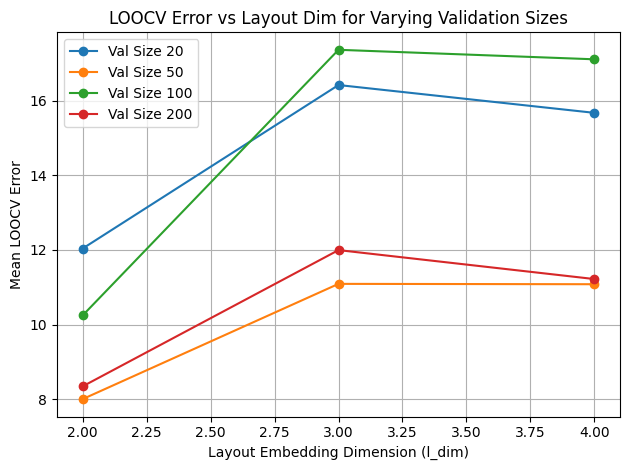

In [50]:
plot_loocv_lines(results, l_dims, s_dims, val_sizes)

In [51]:
def plot_loocv_lines_val(val_sizes, results_list, l_dims, s_dims):
    """
    Plot a line for each (l_dim, s_dim) pair showing LOOCV error vs validation set size.

    Args:
        val_sizes: list of validation sizes
        results_list: list of results from run_cv_fixed_train_size (one per val_size)
        l_dims: list of layout embedding dimensions
        s_dims: list of signal embedding dimensions
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Prepare color cycle
    plt.figure(figsize=(10, 6))

    # For each (l_dim, s_dim) pair
    for i, l in enumerate(l_dims):
        for j, s in enumerate(s_dims):
            errors = [res['error_matrix'][i, j] for res in results_list]
            plt.plot(val_sizes, errors, marker='o', label=f"(l={l}, s={s})")

    plt.xlabel("Validation Set Size")
    plt.ylabel("LOOCV Error")
    plt.title("LOOCV Error vs Validation Set Size for Each (l_dim, s_dim)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


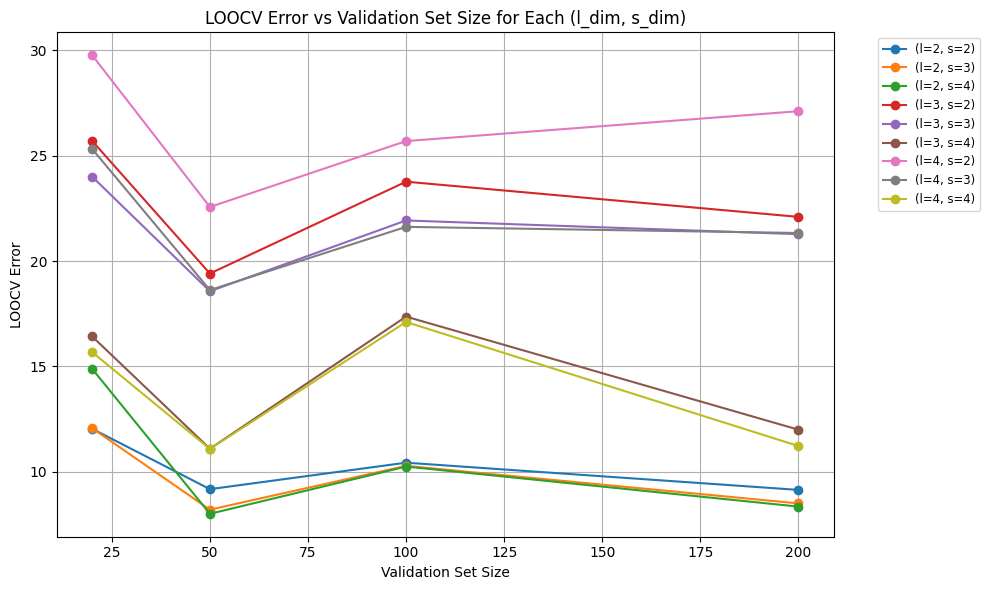

In [52]:
plot_loocv_lines_val(val_sizes, results, l_dims, s_dims)


SSL vs MM (comparison number of labeled points) 

# SSL vs MM : Validation Error against number of labeled points 

In [53]:
def run_cv_varying_train_size(layout_graph, signal_graph, shared_indices, l_dim, s_dim, train_sizes, val_size):
    """
    Cross-validation with varying number of labeled (training) points.
    For each train size, compares SSL and standard Manifold Matching.

    Args:
        layout_graph: instance of PhysicalLayoutGraph
        signal_graph: instance of SignalGraph
        shared_indices: list of indices with known correspondence
        l_dim: fixed layout embedding dimension
        s_dim: fixed signal embedding dimension
        train_sizes: list of integers (number of labeled points)
        val_size: number of validation points (held out)

    Returns:
        results: list of dicts, each containing:
            {
                'train_size': int,
                'ssl_error': float,
                'mm_error': float
            }
    """

    # np.random.seed(42)
    shared_indices = np.array(shared_indices)
    results = []

    # Compute embeddings
    layout_graph._compute_embedding(l_dim)
    signal_graph._compute_embedding(s_dim)
    
    for train_size in train_sizes:
        if train_size + val_size > len(shared_indices):
            raise ValueError(f"train_size + val_size exceeds number of shared points: {train_size + val_size} > {len(shared_indices)}")

        # Subsample shared indices
        # selected_indices = np.random.choice(shared_indices, train_size + val_size, replace=False)
        train_idx = shared_indices[:train_size]
        val_idx = shared_indices[-val_size:]

        # ---- SSL ----
        ssl = MatcherSSL()
        ssl.fit(layout_graph, signal_graph, labeled_indices=train_idx)
        ssl_pred = ssl.predict(val_idx)
        ssl_true = layout_graph.get_points()[val_idx]
        ssl_error = np.mean(np.linalg.norm(ssl_pred - ssl_true, axis=1))

        # ---- Manifold Matching ----
        mm = ManifoldMatcher(layout_graph, signal_graph)
        mm.fit(train_idx)
        mm_pred = mm.predict(val_idx)
        mm_true = layout_graph.get_points()[val_idx]
        mm_error = np.mean(np.linalg.norm(mm_pred - mm_true, axis=1))

        results.append({
            'train_size': train_size,
            'ssl_error': ssl_error,
            'mm_error': mm_error
        })

    return results


In [54]:
val_size = 500

l_dim, s_dim = 2,3
labeled_point_counts = [1,3, 5,7, 10,12, 15, 18,20, 30,50]

results = run_cv_varying_train_size(area_graph, signal_graph, shared_indices, l_dim, s_dim, labeled_point_counts, val_size)


3
phi_S_dim :(1, 3), A_dim:(1, 2), C dim (3, 2), 
[[ 979.75727096 -352.524285  ]
 [ -84.29958546   30.33164639]
 [-730.40038374  262.8037379 ]]
phi_S_dim :(1, 3), A_emb_dim:(1, 2), 
phi_S_dim :(3, 3), A_dim:(3, 2), C dim (3, 2), 
[[ 1290.6692322   -619.87438203]
 [ -291.47823666 -1478.83582146]
 [ -289.43220213    78.36241979]]
phi_S_dim :(3, 3), A_emb_dim:(3, 2), 
phi_S_dim :(5, 3), A_dim:(5, 2), C dim (3, 2), 
[[ 1640.11158613  -132.32392153]
 [   42.1597229  -1012.93654119]
 [ -208.1602697    327.55641382]]
phi_S_dim :(5, 3), A_emb_dim:(5, 2), 
phi_S_dim :(7, 3), A_dim:(7, 2), C dim (3, 2), 
[[ 1.63827885e+03 -1.47428840e+02]
 [ 1.27965145e+00 -9.00311479e+02]
 [-1.71940070e+02  2.39488577e+02]]
phi_S_dim :(7, 3), A_emb_dim:(7, 2), 
phi_S_dim :(10, 3), A_dim:(10, 2), C dim (3, 2), 
[[ 1.58774937e+03 -8.39471735e+01]
 [-1.43884008e-01 -1.01464610e+03]
 [-1.12321093e+02  1.72384256e+02]]
phi_S_dim :(10, 3), A_emb_dim:(10, 2), 
phi_S_dim :(12, 3), A_dim:(12, 2), C dim (3, 2), 
[[ 1573.

In [55]:
def plot_validation_error_vs_labeled_points(results):
    """
    Plot validation error vs number of labeled points for both SSL and Manifold Matching.

    Args:
        results: list of dicts, each with keys:
            'train_size' (int), 'ssl_error' (float), 'mm_error' (float)
    """
    train_sizes = [r['train_size'] for r in results]
    ssl_errors = [r['ssl_error'] for r in results]
    mm_errors = [r['mm_error'] for r in results]

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, ssl_errors, marker='o', label='SSL', linestyle='-', linewidth=2)
    plt.plot(train_sizes, mm_errors, marker='s', label='Manifold Matching', linestyle='--', linewidth=2)
    plt.xlabel("Number of Labeled Points")
    plt.ylabel("Validation Error")
    plt.title("Validation Error vs Number of Labeled Points")
    plt.grid(True)
    plt.legend()
    plt.xticks(train_sizes)  
    plt.tight_layout()
    plt.show()


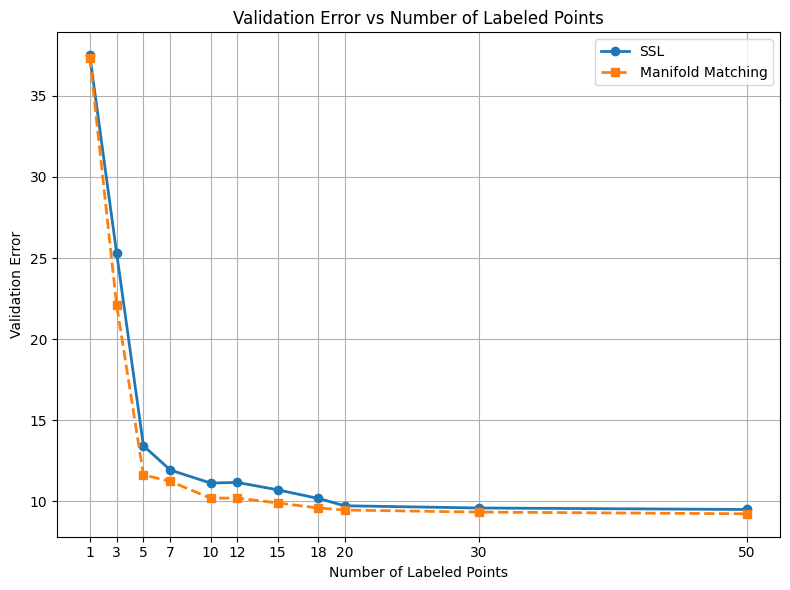

In [56]:
plot_validation_error_vs_labeled_points(results)
